# No-gaze analysis pipeline

This notebook reproduces the steps used for:

- reading the CSV files
- normalizing Student IDs
- merging assignment + pre + post data
- building questionnaire composites
- computing reliability (Cronbach's alpha)
- performing manipulation checks
- reshaping ad-level responses
- running the no-gaze hypothesis tests
- drawing figures from the analysis results

It is written for the files currently stored in `/mnt/data`.


In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.api as sm

from pathlib import Path

ASSIGN_PATH = Path("assignment_MAX45_beverage_can_repeat - Summary.csv")
PRE_PATH    = Path("Copy of Pre-Experiment Questionnaire (事前質問) (Responses) - Form Responses 1 (1).csv")
POST_PATH   = Path("Copy of Post-Experiment Questionnaire (事後質問) (Responses) - Form Responses 1 (1).csv")

OUTPUT_DIR = Path("analysis_outputs_no_gaze")
OUTPUT_DIR.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 200)


## 1. Helper functions

In [2]:
def read_csv_fallback(path):
    for enc in ["utf-8", "utf-8-sig", "cp932", "shift_jis", "latin1"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            continue
    raise ValueError(f"Could not read CSV: {path}")

def normalize_text(s):
    if pd.isna(s):
        return np.nan
    s = str(s)
    s = unicodedata.normalize("NFKC", s)
    s = s.strip()
    return s

def normalize_id(s):
    if pd.isna(s):
        return np.nan
    s = normalize_text(s)
    s = s.upper()
    s = re.sub(r"\s+", "", s)
    return s

def normalize_group(s):
    if pd.isna(s):
        return np.nan

    s = normalize_text(s).lower()

    # smartwatch first
    if "smartwatch" in s or "smart watch" in s or "watch" in s:
        return "SMARTWATCH"

    # control
    if "control" in s or "none" in s:
        return "CONTROL"

    # AR more strictly
    if s == "ar" or " ar " in f" {s} " or "augmented reality" in s:
        return "AR"

    return s.upper()

def find_cols(df, patterns, exclude=None):
    exclude = exclude or []
    cols = []
    for c in df.columns:
        c0 = str(c)
        if any(p.lower() in c0.lower() for p in patterns) and not any(e.lower() in c0.lower() for e in exclude):
            cols.append(c)
    return cols

def cronbach_alpha(df_items):
    x = df_items.dropna()
    if x.shape[0] < 2 or x.shape[1] < 2:
        return np.nan
    item_vars = x.var(axis=0, ddof=1)
    total_var = x.sum(axis=1).var(ddof=1)
    k = x.shape[1]
    if total_var == 0:
        return np.nan
    return (k / (k - 1.0)) * (1 - item_vars.sum() / total_var)

def reverse_code(series, min_val, max_val):
    return max_val + min_val - pd.to_numeric(series, errors="coerce")

def safe_mean(df, cols):
    return df[cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

def to_numeric_df(df, cols):
    out = df[cols].copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def parse_yes_no_not_sure(x):
    if pd.isna(x):
        return np.nan
    s = normalize_text(x).lower()
    if "yes" in s or "はい" in s:
        return 1
    if "no" in s or "いいえ" in s:
        return 0
    if "not sure" in s or "わから" in s:
        return np.nan
    return np.nan

def parse_manipulation_group(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()
    s_upper = s.upper()

    # Not sure / unknown
    if (
        "NOT SURE" in s_upper
        or "よく分からない" in s
        or "よくわからない" in s
        or "分からない" in s
        or "わからない" in s
    ):
        return np.nan

    # Smartwatch must be checked before AR
    # because "SMARTWATCH" contains "AR"
    if (
        "SMARTWATCH GROUP" in s_upper
        or "SMARTWATCH PROMPTS" in s_upper
        or "SMART WATCH" in s_upper
        or "スマートウォッチ" in s
    ):
        return "SMARTWATCH"

    if (
        "CONTROL GROUP" in s_upper
        or "IN-STORE ONLY" in s_upper
        or "NO WEARABLE AD PROMPTS" in s_upper
        or "店内広告のみ" in s
        or "装着デバイスからの広告提示はなく" in s
    ):
        return "CONTROL"

    if (
        "AR GROUP" in s_upper
        or re.search(r"\bAR\b", s_upper)
        or "HEADSET" in s_upper
        or "ヘッドセット" in s
    ):
        return "AR"

    return np.nan

def winner_counts_from_tlx(df, pair_cols):
    dims = {
        "mental": ["mental demand", "知的"],
        "physical": ["physical demand", "身体的要求"],
        "temporal": ["temporal demand", "タイム"],
        "performance": ["performance", "作業成績"],
        "effort": ["effort", "努力"],
        "frustration": ["frustration", "フラスト"],
    }
    def which_dim(value):
        s = normalize_text(value).lower()
        for dim, keys in dims.items():
            if any(k.lower() in s for k in keys):
                return dim
        return np.nan
    out = pd.DataFrame(index=df.index)
    for dim in dims:
        out[f"weight_{dim}"] = 0
    for c in pair_cols:
        chosen = df[c].apply(which_dim)
        for dim in dims:
            out.loc[chosen == dim, f"weight_{dim}"] += 1
    return out

def weighted_tlx(df, rating_cols, pair_cols):
    ratings = pd.DataFrame(index=df.index)
    for dim, col in rating_cols.items():
        ratings[dim] = pd.to_numeric(df[col], errors="coerce")
    weights = winner_counts_from_tlx(df, pair_cols)
    num = (
        ratings["mental"] * weights["weight_mental"] +
        ratings["physical"] * weights["weight_physical"] +
        ratings["temporal"] * weights["weight_temporal"] +
        ratings["performance"] * weights["weight_performance"] +
        ratings["effort"] * weights["weight_effort"] +
        ratings["frustration"] * weights["weight_frustration"]
    )
    den = weights.sum(axis=1).replace(0, np.nan)
    return num / den

def robust_ols(formula, data):
    return smf.ols(formula, data=data).fit(cov_type="HC3")

def clustered_ols(formula, data, cluster_col):
    return smf.ols(formula, data=data).fit(
        cov_type="cluster",
        cov_kwds={"groups": data[cluster_col]}
    )

def robust_logit(formula, data):
    model = smf.logit(formula, data=data).fit(disp=False)
    return model._get_robustcov_results(cov_type="HC3")

def omnibus_p_for_factor(model, factor_prefix):
    names = [n for n in model.params.index if factor_prefix in n]
    if not names:
        return np.nan
    R = np.zeros((len(names), len(model.params)))
    for i, name in enumerate(names):
        R[i, list(model.params.index).index(name)] = 1
    w = model.wald_test(R)
    return float(w.pvalue)

def product_root(ad_str):
    if pd.isna(ad_str):
        return np.nan
    s = normalize_text(ad_str)
    s = re.sub(r"_(NONE|BOGO|50OFF|50_OFF)$", "", s, flags=re.IGNORECASE)
    return s

def parse_discount_from_ad(ad_str):
    if pd.isna(ad_str):
        return np.nan
    s = normalize_text(ad_str).upper()
    if "BOGO" in s:
        return "BOGO"
    if "50OFF" in s or "50_OFF" in s or "50%" in s:
        return "50OFF"
    if "NONE" in s:
        return "NONE"
    return np.nan

BEVERAGES = {
    "STARBUCKS_LATTE_CAN",
    "STARBUCKS_BLACK_CAN",
    "SPRITE_CAN",
    "COCA_COLA_ZERO_CAN",
    "FANTA_GRAPE_CAN",
    "FANTA_ORANGE_CAN",
    "MITSUYA_BOTTLE",
    "OICHA_BOTTLE",
    "FANTA_GRAPE_BOTTLE",
    "COLA_BOTTLE",
    "FANTA_ORANGE_BOTTLE",
    "CALPIS_BOTTLE",
}

CHOCOLATES = {
    "ALFORT_BLUE",
    "ALFORT_WHITE",
    "ALFORT_BROWN",
    "CRUNKY_STRAWBERRY",
    "CRUNKY_CHOCO",
    "COOKIE_CHOCOCHIP",
    "COOKIE_WHITE",
    "COOKIE_ALMOND",
    "COOKIE_MOONLIGHT",
    "COOKIE_BLACKLIGHT",
    "GHANA_RED",
    "GHANA_BLACK",
    "GHANA_WHITE",
    "GHANA_ORANGE",
    "COALA_MARCH_ORIGINAL",
    "COALA_MARCH_STRAWBERRY",
    "COALA_MARCH_BARLEY",
    "POCKY_ORIGINAL",
    "POCKY_ALMOND",
    "POCKY_MATCHA",
    "POCKY_STRAWBERRY",
    "POCKY_WHITE",
    "CHOCO_BISCUIT",
    "KITKAT_PURPLE",
    "KITKAT_AUTUMN",
    "KITKAT_RED",
    "KITKAT_MATCHA",
    "KITKAT_LATTE",
    "KITKAT_BLACK",
}

SNACKS = {
    "NOODLE_CUP_ORANGE",
    "NOODLE_CUP_RED",
    "NOODLE_CUP_SEAFOOD",
    "NOODLE_CUP_CLASSIC",
    "NOODLE_CUP_TOMATO",
    "NOODLE_CUP_BLACK",
    "RED_DORITOS_BAG",
    "BLUE_BAG",
    "PINK_BAG",
    "YELLOW_BAG",
    "KARAMUCHO_BAG",
    "WASABI_BAG",
    "PRETZ_ORANGE",
    "PRETZ_PURPLE",
    "PRETZ_TOMATO",
}

def product_category_from_root(root):
    if pd.isna(root):
        return np.nan
    r = normalize_text(root).upper()
    if r in BEVERAGES:
        return "BEVERAGE"
    if r in CHOCOLATES:
        return "CHOCOLATE"
    if r in SNACKS:
        return "SNACK"
    return np.nan

def normalize_category_response(x):
    if pd.isna(x):
        return np.nan
    s = normalize_text(x).lower()
    if "beverage" in s:
        return "BEVERAGE"
    if "chocolate" in s:
        return "CHOCOLATE"
    if "chips" in s or "snack" in s or "cup noodles" in s:
        return "SNACK"
    if "not sure" in s:
        return np.nan
    return np.nan

def normalize_discount_response(x):
    if pd.isna(x):
        return np.nan
    s = normalize_text(x).upper()
    if "BOGO" in s:
        return "BOGO"
    if "50" in s:
        return "50OFF"
    if "NO DISCOUNT" in s or "NONE" in s:
        return "NONE"
    if "NOT SURE" in s:
        return np.nan
    return np.nan

def normalize_brand_response(x):
    if pd.isna(x):
        return np.nan
    s = normalize_text(x).upper()
    s = re.sub(r"[^A-Z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

def normalize_true_root(root):
    if pd.isna(root):
        return np.nan
    s = normalize_text(root).upper()
    s = re.sub(r"[^A-Z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

def brand_match(resp_brand, true_root):
    rb = normalize_brand_response(resp_brand)
    tr = normalize_true_root(true_root)
    if pd.isna(rb) or pd.isna(tr):
        return np.nan
    if rb == tr:
        return 1
    if rb in tr or tr in rb:
        return 1
    rb_tokens = set(rb.split("_"))
    tr_tokens = set(tr.split("_"))
    if len(rb_tokens & tr_tokens) >= max(1, min(len(rb_tokens), 2)):
        return 1
    return 0


## 2. Read the raw CSV files

In [5]:
assign = read_csv_fallback(ASSIGN_PATH)
pre = read_csv_fallback(PRE_PATH)
post = read_csv_fallback(POST_PATH)

print("Assignment shape:", assign.shape)
print("Pre shape:", pre.shape)
print("Post shape:", post.shape)

assign.head(2)
pre.head(2)
# post.head(2)


Assignment shape: (132, 33)
Pre shape: (132, 58)
Post shape: (132, 87)


,Timestamp,Student ID ( 学籍番号 ),Age (年齢),Gender (性別),Occupation / Student status (職業/学生区分),Highest Education (最終学歴),B1. How often do you shop at convenience stores? ( コンビニで買い物をする頻度はどのくらいですか? ),"B2. When I shop at convenience stores, I usually have very little time. ( コンビニで買い物をするとき、たいてい時間があまりない。 )","B3. When you shop at convenience stores, you are usually… ( コンビニで買い物をするとき、普段あなたは... )","B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree まったくそう思わない , 7=Strongly agree 非常にそう思う ) [I often buy things spontaneously (私はよく衝動的に物を買う)]","B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree まったくそう思わない , 7=Strongly agree 非常にそう思う ) [I sometimes buy things without planning to (私はときどき計画せずに物を買ってしまう)]","B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree まったくそう思わない , 7=Strongly agree 非常にそう思う ) [I tend to make unplanned purchases while shopping (買い物中に予定外の購入をしがちだ)]","B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree まったくそう思わない , 7=Strongly agree 非常にそう思う ) [I am more of an ""impulse buyer"" than a ""planner"" (私は「計画型」よりも「衝動買い型」た)]","C1. In-store advertising attitude (1=Strongly disagree まったくそう思わない , 5=Strongly agree 非常にそう思う ) [In-store advertisements help me discover useful products (店内広告は、役に立つ商品を見つける助けになることが多い)]","C1. In-store advertising attitude (1=Strongly disagree まったくそう思わない , 5=Strongly agree 非常にそう思う ) [PoP displays in convenience stores are informative (コンビニのPoP(店頭)表示は情報提供として有益た)]","C1. In-store advertising attitude (1=Strongly disagree まったくそう思わない , 5=Strongly agree 非常にそう思う ) [PoP displays in convenience stores make me aware of particular products while passing through the aisle (コンビニのPoP表示は、通路を歩いているときに特定の商品に気づかせてくれる)]","C1. In-store advertising attitude (1=Strongly disagree まったくそう思わない , 5=Strongly agree 非常にそう思う ) [PoP displays in convenience stores help me find the product/brand I want(コンビニのPoP表示は、欲しい商品やメーカーを見つける助けになる)]","D1. How much experience do you have with AR devices and applications? AR機器/アプリの経験はどの程度ありますか? (1 = Not at all まったくない , 5 = To a great extent 非常にある )","D2. How often do you use a smartwatch (e.g., Apple Watch, Galaxy Watch, Fitbit)? スマートウォッチ(例:Apple Watch, Galaxy Watch, Fitbit)をどのくらい使用しますか? \n\n(1 = Never wear ほとんど着けない , 5 = Always wear 常に着ける)","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please rate your familiarity with each advertised brand. 各商品について、どのくらい親しみを感じるか評価してください [Alfort(アルフォート)]","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please rate your familiarity with each advertised brand. 各商品について、どのくらい親しみを感じるか評価してください [Almond Cookie(アーモンドクッキー)]","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please rate your familiarity with each advertised brand. 各商品について、どのくらい親しみを感じるか評価してください [Blackmoon Chocolat Cookie(ブラックムーンショコラクッキー)]","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please rate your familiarity with each advertised brand. 各商品について、どのくらい親しみを感じるか評価してください [Calbee Potato Wasabi(カルビー ポテト わさび)]","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please rate your familiarity with each advertised brand. 各商品について、どのくらい親しみを感じるか評価してください [Calpis(カルピス)]","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please rate your familiarity with each advertised brand. 各商品について、どのくらい親しみを感じるか評価してください [Choco & Coffee biscuits(チョコ&コーヒービスケット)]","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please rate your familiarity with each advertised brand. 各商品について、どのくらい親しみを感じるか評価してください [Chocochips Cookie(チョコチップクッキー)]","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please rate your familiarity with each advertised brand. 各商品について、どのくらい親しみを感じるか評価してください [Chocochips White Cookie(チョコチップホワイトクッキー)]","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please rate your familiarity with each advertised brand. 各商品について、どのくらい親しみを感じるか評価してください [Coca Cola(コカ・コーラ)]","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please rate your familiarity with each advertised brand. 各商品について、どのくらい親しみを感じるか評価してください [Crunky(クランキー)]","E1. (1 = Unfamiliar 知らない , 7 = Familiar よく知っている ) Please r

## 3. Normalize Student IDs and group labels

In [6]:
assign["id_norm"] = assign["Student ID"].apply(normalize_id)
pre["id_norm"] = pre["Student ID ( 学籍番号 )"].apply(normalize_id)
post["id_norm"] = post["Student ID ( 学籍番号 )"].apply(normalize_id)

assign["group"] = assign["Assigned Group"].apply(normalize_group)

assign = assign[assign["id_norm"].notna()].copy()
assign = assign[~assign["id_norm"].isin(["NAN", "TIMESTARTANDTIMEENDBASEDONARGLASSESVIDEOS"])].copy()
assign = assign.drop_duplicates(subset="id_norm", keep="first")

print("Assignment unique normalized IDs:", assign["id_norm"].nunique())
print("Pre unique normalized IDs:", pre["id_norm"].nunique())
print("Post unique normalized IDs:", post["id_norm"].nunique())

assign[["Student ID","id_norm","Assigned Group","group"]].head(10)


Assignment unique normalized IDs: 132
Pre unique normalized IDs: 132
Post unique normalized IDs: 132


,Student ID,id_norm,Assigned Group,group
0,C5IM2066,C5IM2066,Smartwatch,SMARTWATCH
1,Sato,SATO,Control,CONTROL
2,Wang,WANG,Control,CONTROL
3,Daiki,DAIKI,Smartwatch,SMARTWATCH
4,C4ID2014,C4ID2014,Smartwatch,SMARTWATCH
5,C5IM2502,C5IM2502,Control,CONTROL
6,C4IM2022,C4IM2022,AR,AR
7,C4TD9112,C4TD9112,AR,AR
8,C5IE2503,C5IE2503,Control,CONTROL
9,C4SM6701,C4SM6701,AR,AR


## 4. Merge assignment + pre + post

In [7]:
matched = assign.merge(pre, on="id_norm", how="inner", suffixes=("", "_pre"))
matched = matched.merge(post, on="id_norm", how="inner", suffixes=("", "_post"))
matched["student_id"] = matched["id_norm"]

print("Matched subject count:", matched["student_id"].nunique())
matched["group"].value_counts()


Matched subject count: 132


group
SMARTWATCH    44
CONTROL       44
AR            44
Name: count, dtype: int64

In [8]:
group_id_df = (
    matched[["group", "student_id"]]
    .drop_duplicates()
    .sort_values(["group", "student_id"])
    .reset_index(drop=True)
)

# group_id_df.to_csv("student_ids_by_group.csv", index=False)

group_id_df

,group,student_id
0,AR,-
1,AR,12345
2,AR,ABCDEFG
3,AR,C2TB5066
4,AR,C2TB5069
...,...,...
127,SMARTWATCH,C5TM9603
128,SMARTWATCH,C6IM3011
129,SMARTWATCH,DAIKI
130,SMARTWATCH,HONGTHONGPONTAKORN


## 5. Build pre-questionnaire composites

In [9]:
import re
import numpy as np
import pandas as pd

def extract_leading_number(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    m = re.match(r"^([0-9]+(?:\.[0-9]+)?)", s)
    return float(m.group(1)) if m else np.nan

# =============================
# Impulse buying (B4)
# =============================
impulse_cols = find_cols(pre, ["Impulse buying tendency"], exclude=["Timestamp", "Student ID"])
impulse_cols = [c for c in matched.columns if c in impulse_cols]

for c in impulse_cols:
    matched[c] = matched[c].apply(extract_leading_number)

matched["impulse_buying"] = matched[impulse_cols].mean(axis=1)

print("Impulse columns used:", len(impulse_cols))
for c in impulse_cols:
    print(c)

# =============================
# PoP attitude (C)
# =============================
pop_markers = [
    "discover useful products",
    "PoP displays in convenience stores are informative",
    "PoP displays in convenience stores make me aware of particular products",
    "PoP displays in convenience stores help me find the product/brand I want",
]

pop_cols = []
for marker in pop_markers:
    hits = [c for c in matched.columns if marker.lower() in c.lower()]
    if len(hits) == 0:
        print("Missing PoP item:", marker)
    else:
        pop_cols.append(hits[0])

# remove duplicates while keeping order
pop_cols = list(dict.fromkeys(pop_cols))

for c in pop_cols:
    matched[c] = matched[c].apply(extract_leading_number)

matched["pop_attitude"] = matched[pop_cols].mean(axis=1)

print("\nPoP columns used:", len(pop_cols))
for c in pop_cols:
    print(c)

# =============================
# TAEG-S
# =============================

# optional cleanup if you previously created many __rev columns
drop_cols = [c for c in matched.columns if "__rev" in c and "electronic device" in c.lower()]
matched = matched.drop(columns=drop_cols, errors="ignore")

taeg_markers = [
    "I love having new electronic devices",
    "Electronic devices make people sick",
    "Electronic devices enable a high quality of life",
    "intellectual impoverishment",
    "I enjoy trying out electronic devices",
    "Electronic devices make my everyday life easier",
    "Electronic devices make things safer",
    "I know most of the functions of the electronic devices I own",
    "I am excited when a new electronic device comes on the market",
    "Electronic devices cause stress",
    "I know a lot about electronic devices",
    "I find it easy to learn how to operate an electronic device",
]

taeg_cols = []
for marker in taeg_markers:
    hits = [
        c for c in matched.columns
        if marker.lower() in c.lower() and "__rev" not in c
    ]
    if len(hits) == 0:
        print("Missing TAEG item:", marker)
    else:
        taeg_cols.append(hits[0])

# remove duplicates while keeping order
taeg_cols = list(dict.fromkeys(taeg_cols))

print("\nTAEG columns found:", len(taeg_cols))
for c in taeg_cols:
    print(c)

taeg_neg_markers = [
    "make people sick",
    "intellectual impoverishment",
    "cause stress",
]

taeg_use_cols = []

for c in taeg_cols:
    matched[c] = matched[c].apply(extract_leading_number)

    if any(m in c.lower() for m in taeg_neg_markers):
        newc = c + "__rev"
        matched[newc] = reverse_code(matched[c], 1, 5)
        taeg_use_cols.append(newc)
    else:
        taeg_use_cols.append(c)

matched["taeg"] = matched[taeg_use_cols].mean(axis=1)

print("\nTAEG columns used after reverse coding:", len(taeg_use_cols))
for c in taeg_use_cols:
    print(c)

print("\nSummary counts")
print("Impulse:", len(impulse_cols))
print("PoP:", len(pop_cols))
print("TAEG:", len(taeg_cols))

matched[["student_id", "group", "impulse_buying", "pop_attitude", "taeg"]].head()

Impulse columns used: 4
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I often buy things spontaneously (私はよく衝動的に物を買う)]
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I sometimes buy things without planning to (私はときどき計画せずに物を買ってしまう)]
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I tend to make unplanned purchases while shopping (買い物中に予定外の購入をしがちだ)]
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I am more of an "impulse buyer" than a "planner" (私は「計画型」よりも「衝動買い型」た)]

PoP columns used: 4
C1. In-store advertising attitude (1=Strongly disagree  まったくそう思わない  , 5=Strongly agree  非常にそう思う  ) [In-store advertisements help me discover useful products (店内広告は、役に立つ商品を見つける助けになることが多い)]
C1. In-store advertising attitude (1=Strongly disagree  まったくそう思わない  , 5=St

,student_id,group,impulse_buying,pop_attitude,taeg
0,C5IM2066,SMARTWATCH,3.25,3.25,4.333333
1,SATO,CONTROL,4.50,3.25,4.333333
2,WANG,CONTROL,1.75,3.25,3.833333
3,DAIKI,SMARTWATCH,5.50,4.50,4.250000
4,C4ID2014,SMARTWATCH,3.00,2.25,3.916667


In [10]:
# ============================================================
# Show calculation details for ONE example row
# For impulse_buying, pop_attitude, and TAEG-S
# Paste this after your current block
# ============================================================

example_idx = matched.index[0]   # change this if you want another participant
r = matched.loc[example_idx]

print("====================================================")
print("EXAMPLE ROW")
print("====================================================")
print("student_id:", r["student_id"])
print("group:", r["group"])


# ============================================================
# 1. Impulse buying calculation
# ============================================================

print("\n--- Impulse buying ---")
print("Scale: 1 = Strongly disagree, 7 = Strongly agree")

impulse_values = []

for col in impulse_cols:
    value = r[col]
    impulse_values.append(value)
    print(f"{col}: {value}")

impulse_valid_values = [v for v in impulse_values if pd.notna(v)]

print("\nFormula:")
print("impulse_buying = mean of impulse buying items")
print("number of valid impulse items =", len(impulse_valid_values))

if len(impulse_valid_values) > 0:
    print("calculated impulse_buying =", np.mean(impulse_valid_values))
else:
    print("calculated impulse_buying = NaN because there are no valid impulse items")

print("stored impulse_buying =", r["impulse_buying"])


# ============================================================
# 2. PoP attitude calculation
# ============================================================

print("\n--- PoP attitude ---")
print("Scale: 1 = Strongly disagree, 5 = Strongly agree")

pop_values = []

for col in pop_cols:
    value = r[col]
    pop_values.append(value)
    print(f"{col}: {value}")

pop_valid_values = [v for v in pop_values if pd.notna(v)]

print("\nFormula:")
print("pop_attitude = mean of PoP attitude items")
print("number of valid PoP items =", len(pop_valid_values))

if len(pop_valid_values) > 0:
    print("calculated pop_attitude =", np.mean(pop_valid_values))
else:
    print("calculated pop_attitude = NaN because there are no valid PoP items")

print("stored pop_attitude =", r["pop_attitude"])


# ============================================================
# 3. TAEG-S calculation
# ============================================================

print("\n--- TAEG-S ---")
print("Scale: 1 = Strongly disagree, 5 = Strongly agree")
print("Negative items are reverse-coded: reversed value = 6 - raw value")

taeg_values = []

for col in taeg_use_cols:
    value = r[col]
    taeg_values.append(value)

    if col.endswith("__rev"):
        original_col = col.replace("__rev", "")
        original_value = r[original_col]
        print(f"{original_col}: raw = {original_value}, reversed = 6 - {original_value} = {value}")
    else:
        print(f"{col}: value = {value}")

taeg_valid_values = [v for v in taeg_values if pd.notna(v)]

print("\nFormula:")
print("taeg = mean of TAEG-S items after reverse coding negative items")
print("number of valid TAEG-S items =", len(taeg_valid_values))

if len(taeg_valid_values) > 0:
    print("calculated taeg =", np.mean(taeg_valid_values))
else:
    print("calculated taeg = NaN because there are no valid TAEG-S items")

print("stored taeg =", r["taeg"])

EXAMPLE ROW
student_id: C5IM2066
group: SMARTWATCH

--- Impulse buying ---
Scale: 1 = Strongly disagree, 7 = Strongly agree
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I often buy things spontaneously (私はよく衝動的に物を買う)]: 4.0
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I sometimes buy things without planning to (私はときどき計画せずに物を買ってしまう)]: 3.0
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I tend to make unplanned purchases while shopping (買い物中に予定外の購入をしがちだ)]: 3.0
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I am more of an "impulse buyer" than a "planner" (私は「計画型」よりも「衝動買い型」た)]: 3.0

Formula:
impulse_buying = mean of impulse buying items
number of valid impulse items = 4
calculated impulse_buying = 3.25
stored impulse_buying = 3.25

--- PoP att

In [11]:
print("Impulse columns:")
for c in impulse_cols:
    print(c)

print("\nPoP columns:")
for c in pop_cols:
    print(c)

print("\nTAEG columns:")
for c in taeg_cols:
    print(c)

print("\nTAEG used columns after reverse coding:")
for c in taeg_use_cols:
    print(c)

Impulse columns:
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I often buy things spontaneously (私はよく衝動的に物を買う)]
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I sometimes buy things without planning to (私はときどき計画せずに物を買ってしまう)]
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I tend to make unplanned purchases while shopping (買い物中に予定外の購入をしがちだ)]
B4. Impulse buying tendency ( 衝動買いに関する傾向) (1=Strongly disagree  まったくそう思わない  , 7=Strongly agree  非常にそう思う  ) [I am more of an "impulse buyer" than a "planner" (私は「計画型」よりも「衝動買い型」た)]

PoP columns:
C1. In-store advertising attitude (1=Strongly disagree  まったくそう思わない  , 5=Strongly agree  非常にそう思う  ) [In-store advertisements help me discover useful products (店内広告は、役に立つ商品を見つける助けになることが多い)]
C1. In-store advertising attitude (1=Strongly disagree  まったくそう思わない  , 5=Strongly agree  

In [12]:
print("n impulse_cols =", len(impulse_cols))
print("n pop_cols    =", len(pop_cols))
print("n taeg_cols   =", len(taeg_cols))
print("n taeg_use_cols =", len(taeg_use_cols))
matched[["student_id", "group"] + impulse_cols].head()
# matched[["student_id", "group"] + pop_cols].head()
# matched[["student_id", "group"] + taeg_cols].head()
matched[["student_id", "group"] + taeg_use_cols].head()

n impulse_cols = 4
n pop_cols    = 4
n taeg_cols   = 12
n taeg_use_cols = 12


,student_id,group,"Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [I love having new electronic devices. 新しい電子機器を入手するのが好きだ]","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [Electronic devices make people sick. 電子機器を使うと気分が悪くなる]__rev","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [Electronic devices enable a high quality of life. 電子機器によって質の高い生活ができる]","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [Electronic devices lead to intellectual impoverishment 電子機器は精神的な疲弊をもたらす]__rev","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [I enjoy trying out electronic devices. 電子機器を試してみるのは、自分にとって楽しいことだ]","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [Electronic devices make my everyday life easier. 電子機器は毎日の生活を楽にしてくれる]","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [Electronic devices make things safer. 電子機器によって安全性を高めることができる]","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [I know most of the functions of the electronic devices I own. 自分が持っている電子機器の機能の大部分を知っている]","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [I am excited when a new electronic device comes on the market. 新しい電子機器が発売されると、わくわくする]","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [Electronic devices cause stress. 電子機器はストレスの原因になる]__rev","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [I know a lot about electronic devices. 電子機器の使い方をよく知っている]","Below you will find a series of statements. For each statement, please indicate how it applies to you personally. To do so, check the box on the right that best matches your opinion.\n下記の各項目について、あなた自身にどの程度あてはまるかをお答えください。その際、あなたの意見に最も近いボックスにチェックを入れてください。\n [I find it easy to learn how to operate an electronic device. 電子機器の使い方を覚えるのは簡単だ]"
0,C5IM2066,SMARTWATCH,5.0,5.0,5.0,4.0,4.0,4.0,4

## 6. Build post-questionnaire composites

In [13]:
def extract_likert_number(x, min_val=None, max_val=None):
    """
    Extract the first number from Likert-style answers such as:
    '1 Strongly disagree'
    '5 Strongly agree'
    '7 Strongly agree'
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    # If already numeric
    try:
        value = float(s)
    except ValueError:
        match = re.search(r"\d+(\.\d+)?", s)
        if match is None:
            return np.nan
        value = float(match.group())

    if min_val is not None and value < min_val:
        return np.nan

    if max_val is not None and value > max_val:
        return np.nan

    return value

# ============================================================
# Manipulation check
# ============================================================

manip_col = find_cols(post, ["Which ad-delivery method did you experience most clearly"])[0]
matched["manip_group"] = matched[manip_col].apply(parse_manipulation_group)


# ============================================================
# Category-level noticing
# Beverage / Chocolate / Snack
# ============================================================

bev_notice_col = [c for c in matched.columns if "notice it during the task" in c and "Beverage Ad" in c][0]
choc_notice_col = [c for c in matched.columns if "notice it during the task" in c and "Chocolate Ad" in c][0]
snack_notice_col = [c for c in matched.columns if "notice it during the task" in c and "Chips/cup noodles/snacks" in c][0]

matched["noticed_beverage"] = matched[bev_notice_col].apply(parse_yes_no_not_sure)
matched["noticed_chocolate"] = matched[choc_notice_col].apply(parse_yes_no_not_sure)
matched["noticed_snack"] = matched[snack_notice_col].apply(parse_yes_no_not_sure)

matched["noticed_any"] = matched[
    ["noticed_beverage", "noticed_chocolate", "noticed_snack"]
].max(axis=1)

matched["noticed_n"] = matched[
    ["noticed_beverage", "noticed_chocolate", "noticed_snack"]
].fillna(0).sum(axis=1)

matched["noticed_all3"] = (matched["noticed_n"] == 3).astype(int)


# ============================================================
# Self-reported AD exposure from Post-Questionnaire
# AD1 = _None
# AD2 = _BOGO
# AD3 = _50OFF
# Not based on product category
# ============================================================

def find_ad_exposure_col(ad_num):
    """
    Find the post-questionnaire column asking whether participant saw AD1/AD2/AD3.
    This is different from Beverage/Chocolate/Snack noticing.
    """

    patterns = [
        rf"\bAD\s*{ad_num}\b",
        rf"\[AD\s*{ad_num}\b",
        rf"AD{ad_num}\b",
    ]

    candidates = []

    for c in matched.columns:
        col = str(c)
        col_lower = col.lower()

        has_ad_num = any(re.search(p, col, flags=re.IGNORECASE) for p in patterns)

        has_exposure_text = (
            "did you see this ad" in col_lower
            or "see this ad during the task" in col_lower
            or "exposure check" in col_lower
            or "notice it during the task" in col_lower
        )

        if has_ad_num and has_exposure_text:
            candidates.append(c)

    if len(candidates) == 0:
        print(f"\nCould not find AD{ad_num} exposure column.")
        print("Columns containing AD:")
        for c in matched.columns:
            if re.search(r"\bAD\s*\d|\bAD\d", str(c), flags=re.IGNORECASE):
                print(c)
        raise ValueError(f"Could not find exposure check column for AD{ad_num}")

    return candidates[0]


ad1_exposure_col = find_ad_exposure_col(1)
ad2_exposure_col = find_ad_exposure_col(2)
ad3_exposure_col = find_ad_exposure_col(3)

print("AD1 exposure column:", ad1_exposure_col)
print("AD2 exposure column:", ad2_exposure_col)
print("AD3 exposure column:", ad3_exposure_col)


matched["reported_saw_ad1_none"] = matched[ad1_exposure_col].apply(parse_yes_no_not_sure)
matched["reported_saw_ad2_bogo"] = matched[ad2_exposure_col].apply(parse_yes_no_not_sure)
matched["reported_saw_ad3_50off"] = matched[ad3_exposure_col].apply(parse_yes_no_not_sure)

reported_ad_cols = [
    "reported_saw_ad1_none",
    "reported_saw_ad2_bogo",
    "reported_saw_ad3_50off",
]

matched["reported_saw_any"] = matched[reported_ad_cols].max(axis=1)

matched["reported_saw_n"] = matched[
    reported_ad_cols
].fillna(0).sum(axis=1)

matched["reported_saw_all3"] = (matched["reported_saw_n"] == 3).astype(int)


def get_reported_saw_ads(row):
    ads = []

    if row["reported_saw_ad1_none"] == 1:
        ads.append("AD1_None")

    if row["reported_saw_ad2_bogo"] == 1:
        ads.append("AD2_BOGO")

    if row["reported_saw_ad3_50off"] == 1:
        ads.append("AD3_50OFF")

    return ads


matched["reported_saw_ads_list"] = matched.apply(get_reported_saw_ads, axis=1)

matched["reported_saw_ads"] = matched["reported_saw_ads_list"].apply(
    lambda x: "; ".join(x) if len(x) > 0 else "None"
)

# Keep raw post-questionnaire answers
matched["reported_saw_ad1_none_raw"] = matched[ad1_exposure_col]
matched["reported_saw_ad2_bogo_raw"] = matched[ad2_exposure_col]
matched["reported_saw_ad3_50off_raw"] = matched[ad3_exposure_col]


# ============================================================
# NASA-TLX
# ============================================================

rating_cols = {
    "mental": [c for c in matched.columns if c.startswith("Mental Demand")][0],
    "physical": [c for c in matched.columns if c.startswith("Physical Demand")][0],
    "temporal": [c for c in matched.columns if c.startswith("Temporal Demand")][0],
    "performance": [c for c in matched.columns if c.startswith("Performance")][0],
    "effort": [c for c in matched.columns if c.startswith("Effort")][0],
    "frustration": [c for c in matched.columns if c.startswith("Frustration")][0],
}

pair_cols = [c for c in matched.columns if re.match(r"^\d{2}\.", str(c))]
matched["tlx_weighted"] = weighted_tlx(matched, rating_cols, pair_cols)



# ============================================================
# UES-SF
# 1 = Strongly disagree
# 5 = Strongly agree
# ============================================================

ues_cols = [c for c in matched.columns if "UES-SF" in c]
ues_neg_markers = ["frustrated", "confusing", "taxing"]

ues_use_cols = []

for c in ues_cols:
    # Extract only the numeric Likert value from answers like "1 Strongly disagree"
    matched[c] = matched[c].apply(lambda x: extract_likert_number(x, 1, 5))

    if any(m in c.lower() for m in ues_neg_markers):
        newc = c + "__rev"

        # Reverse coding for 1–5 scale:
        # 1 -> 5, 2 -> 4, 3 -> 3, 4 -> 2, 5 -> 1
        matched[newc] = reverse_code(matched[c], 1, 5)
        ues_use_cols.append(newc)
    else:
        ues_use_cols.append(c)

matched["ues"] = safe_mean(matched, ues_use_cols)


# ============================================================
# True ad exposure from assignment file
# Based on True Saw AD1, True Saw AD2, True Saw AD3
# ============================================================

true_saw_cols = ["True Saw AD1", "True Saw AD2", "True Saw AD3"]

if not all(c in matched.columns for c in true_saw_cols):

    assignment = pd.read_csv(ASSIGN_PATH)

    def norm_id(x):
        if pd.isna(x):
            return np.nan
        return re.sub(r"\s+", "", str(x).strip().upper())

    matched["_sid_key"] = matched["student_id"].apply(norm_id)
    assignment["_sid_key"] = assignment["Student ID"].apply(norm_id)

    assignment_true_saw = assignment[
        ["_sid_key"] + true_saw_cols
    ].drop_duplicates("_sid_key")

    matched = matched.merge(
        assignment_true_saw,
        on="_sid_key",
        how="left",
        validate="m:1"
    )


def parse_true_saw(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().upper()
    original = str(x).strip()

    if s in ["YES", "Y", "TRUE", "T", "1", "SAW"]:
        return 1

    if s in ["NO", "N", "FALSE", "F", "0", "NOT SAW", "DID NOT SEE"]:
        return 0

    if "見ていない" in original or "見なかった" in original:
        return 0

    if "見た" in original:
        return 1

    if "YES" in s or "TRUE" in s or "SAW" in s:
        return 1

    if "NO" in s or "FALSE" in s or "DID NOT" in s:
        return 0

    return np.nan


for c in true_saw_cols:
    matched[c + "_bin"] = matched[c].apply(parse_true_saw)

true_saw_bin_cols = [c + "_bin" for c in true_saw_cols]

matched["true_saw_any"] = matched[true_saw_bin_cols].max(axis=1)

matched["true_saw_n"] = matched[
    true_saw_bin_cols
].fillna(0).sum(axis=1)

matched["true_saw_all3"] = (matched["true_saw_n"] == 3).astype(int)


# ============================================================
# True saw ad names
# AD1 = _None
# AD2 = _BOGO
# AD3 = _50OFF
# ============================================================

def get_true_saw_ads(row):
    ads = []

    if row["True Saw AD1_bin"] == 1:
        ads.append("AD1_None")

    if row["True Saw AD2_bin"] == 1:
        ads.append("AD2_BOGO")

    if row["True Saw AD3_bin"] == 1:
        ads.append("AD3_50OFF")

    return ads


matched["true_saw_ads_list"] = matched.apply(get_true_saw_ads, axis=1)

matched["true_saw_ads"] = matched["true_saw_ads_list"].apply(
    lambda x: "; ".join(x) if len(x) > 0 else "None"
)


# ============================================================
# Aad
# 1 = Strongly disagree
# 7 = Strongly agree
# Calculated only for participants who truly saw at least one ad
# ============================================================

aad_cols = [
    c for c in matched.columns
    if "Overall, the advertisements I saw in this experiment were" in c
]

for c in aad_cols:
    # Extract only the numeric Likert value from answers like "7 Strongly agree"
    matched[c] = matched[c].apply(lambda x: extract_likert_number(x, 1, 7))

matched["aad"] = np.nan

true_saw_mask = matched["true_saw_any"] == 1

matched.loc[true_saw_mask, "aad"] = safe_mean(
    matched.loc[true_saw_mask],
    aad_cols
)

# ============================================================
# Check summary
# ============================================================

print("Participants who reported seeing at least one AD1/AD2/AD3:", matched["reported_saw_any"].sum())
print("Participants who truly saw at least one AD1/AD2/AD3:", true_saw_mask.sum())
print("Participants with Aad score:", matched["aad"].notna().sum())


# ============================================================
# Print first 20 rows
# ============================================================

check_cols = [
    "student_id",
    "group",

    # Self-reported AD exposure from post questionnaire
    "reported_saw_ad1_none_raw",
    "reported_saw_ad2_bogo_raw",
    "reported_saw_ad3_50off_raw",
    "reported_saw_ads",
    "reported_saw_n",
    "reported_saw_any",

    # True exposure from assignment file
    "True Saw AD1",
    "True Saw AD2",
    "True Saw AD3",
    "true_saw_ads",
    "true_saw_n",
    "true_saw_any",

    # Category-level noticing
    "noticed_beverage",
    "noticed_chocolate",
    "noticed_snack",
    "noticed_n",

    # Outcomes
    "tlx_weighted",
    "ues",
    "aad",
]

matched[check_cols].head(20)


# # ============================================================
# # Participants who truly saw ads but have missing Aad
# # ============================================================

# missing_aad_after_true_saw = matched[
#     (matched["true_saw_any"] == 1) &
#     (matched["aad"].isna())
# ][
#     [
#         "student_id",
#         "group",
#         "true_saw_ads",
#         "true_saw_any",
#         "true_saw_n",
#     ] +
#     true_saw_cols +
#     aad_cols
# ]

# missing_aad_after_true_saw

AD1 exposure column: [AD 1  広告1] A. Exposure check: Did you see this ad during the task?
    買い物体験中にこの広告を見ましたか
AD2 exposure column: [AD 2   広告2] A. Exposure check: Did you see this ad during the task?
    買い物体験中にこの広告を見ましたか
AD3 exposure column: [AD 3   広告3 ] A. Exposure check: Did you see this ad during the task?
    買い物体験中にこの広告を見ましたか
Participants who reported seeing at least one AD1/AD2/AD3: 97
Participants who truly saw at least one AD1/AD2/AD3: 96
Participants with Aad score: 95


,student_id,group,reported_saw_ad1_none_raw,reported_saw_ad2_bogo_raw,reported_saw_ad3_50off_raw,reported_saw_ads,reported_saw_n,reported_saw_any,True Saw AD1,True Saw AD2,True Saw AD3,true_saw_ads,true_saw_n,true_saw_any,noticed_beverage,noticed_chocolate,noticed_snack,noticed_n,tlx_weighted,ues,aad
0,C5IM2066,SMARTWATCH,Yes はい,Yes はい,Yes はい,AD1_None; AD2_BOGO; AD3_50OFF,3,1,Yes,Yes,Yes,AD1_None; AD2_BOGO; AD3_50OFF,3,1,1,1,1,3,32.000000,4.000000,5.75
1,SATO,CONTROL,Yes はい,Yes はい,Yes はい,AD1_None; AD2_BOGO; AD3_50OFF,3,1,Yes,Yes,Yes,AD1_None; AD2_BOGO; AD3_50OFF,3,1,1,1,1,3,33.000000,3.916667,4.25
2,WANG,CONTROL,Not sure わからない,Yes はい,Yes はい,AD2_BOGO; AD3_50OFF,2,1,Yes,Yes,Yes,AD1_None; AD2_BOGO; AD3_50OFF,3,1,1,1,1,3,22.000000,3.833333,5.25
3,DAIKI,SMARTWATCH,Yes はい,Yes はい,Yes はい,AD1_None; AD2_BOGO; AD3_50OFF,3,1,Yes,Yes,Yes,AD1_None; AD2_BOGO; AD3_50OFF,3,1,1,1,1,3,96.666667,4.833333,6.00
4,C4ID2014,SMARTWATCH,Yes はい,No いいえ,Yes はい,AD1_None; AD3_50OFF,2,1,Yes,No,Yes,AD1_None; AD3_50OFF,2,1,1,0,1,2,48.000000,3.333333,6.00
5,C5IM2502,CONTROL,Yes はい,Yes はい,Yes はい,AD1_None; AD2_BOGO; AD3_50OFF,3,1,Yes,Yes,Yes,AD1_None; AD2_BOGO; AD3_50OFF,3,1,1,1,1,3,14.666667,3.583333,3.00
6,C4IM2022,AR,Not sure わからない,Yes はい,Yes はい,AD2_BOGO; AD3_50OFF,2,1,Yes,Yes,Yes,AD1_None; AD2_BOGO; AD3_50OFF,3,1,1,1,1,3,47.333333,4.250000,5.75
7,C4TD9112,AR,Yes はい,Yes はい,Yes はい,AD1_None; AD2_BOGO; AD3_50OFF,3,1,Yes,Yes,Yes,AD1_None; AD2_BOGO; AD3_50OFF,3,1,1,1,1,3,29.333333,3.083333,7.00
8,C5IE2503,CONTROL,No いいえ,No いいえ,No いいえ,None,0,0,No,No,No,None,0,0,0,0,0,0,0.000000,3.666667,NaN
9,C4SM6701,AR,Yes はい,Yes はい,No いいえ,AD1_None; AD2_BOGO,2,1,Yes,No,Yes,AD1_None; AD3_50OFF,2,1,1,1,0,2,36.000000,4.083333,4.25


In [14]:
# ============================================================
# Show calculation details for ONE example row
# Paste this after your current updated block
# ============================================================

example_idx = matched.index[0]   # change this if you want another participant
r = matched.loc[example_idx]

print("====================================================")
print("EXAMPLE ROW")
print("====================================================")
print("student_id:", r["student_id"])
print("group:", r["group"])


# ============================================================
# 1. Manipulation check
# ============================================================

print("\n--- Manipulation check ---")
print("Raw answer:")
print(r[manip_col])
print("Parsed manip_group:")
print(r["manip_group"])


# ============================================================
# 2. Category-level noticing calculation
# Beverage / Chocolate / Snack
# ============================================================

print("\n--- Category-level noticing ---")

print("Beverage raw:", r[bev_notice_col])
print("Beverage parsed:", r["noticed_beverage"])

print("Chocolate raw:", r[choc_notice_col])
print("Chocolate parsed:", r["noticed_chocolate"])

print("Snack raw:", r[snack_notice_col])
print("Snack parsed:", r["noticed_snack"])

print("\nnoticed_any = max(noticed_beverage, noticed_chocolate, noticed_snack)")
print("noticed_any =", r["noticed_any"])

print("\nnoticed_n = sum(noticed_beverage, noticed_chocolate, noticed_snack), treating NaN as 0")
print("noticed_n =", r["noticed_n"])

print("\nnoticed_all3 = 1 if noticed_n == 3 else 0")
print("noticed_all3 =", r["noticed_all3"])


# ============================================================
# 3. Self-reported AD exposure calculation
# AD1 = _None, AD2 = _BOGO, AD3 = _50OFF
# ============================================================

print("\n--- Self-reported AD exposure ---")
print("This is based on what the participant filled out in the post-questionnaire.")
print("AD1 = _None")
print("AD2 = _BOGO")
print("AD3 = _50OFF")

print("\nAD1 raw:", r["reported_saw_ad1_none_raw"])
print("AD1 parsed:", r["reported_saw_ad1_none"])

print("AD2 raw:", r["reported_saw_ad2_bogo_raw"])
print("AD2 parsed:", r["reported_saw_ad2_bogo"])

print("AD3 raw:", r["reported_saw_ad3_50off_raw"])
print("AD3 parsed:", r["reported_saw_ad3_50off"])

print("\nreported_saw_ads =", r["reported_saw_ads"])

print("\nreported_saw_any = max(reported_saw_ad1_none, reported_saw_ad2_bogo, reported_saw_ad3_50off)")
print("reported_saw_any =", r["reported_saw_any"])

print("\nreported_saw_n = sum of AD1/AD2/AD3 that participant reported seeing")
print("reported_saw_n =", r["reported_saw_n"])

print("\nreported_saw_all3 = 1 if reported_saw_n == 3 else 0")
print("reported_saw_all3 =", r["reported_saw_all3"])


# ============================================================
# 4. True AD exposure calculation
# From assignment file: True Saw AD1, True Saw AD2, True Saw AD3
# ============================================================

print("\n--- True AD exposure ---")
print("This is based on the assignment / true exposure file.")
print("AD1 = _None")
print("AD2 = _BOGO")
print("AD3 = _50OFF")

print("\nTrue Saw AD1 raw:", r["True Saw AD1"])
print("True Saw AD1 parsed:", r["True Saw AD1_bin"])

print("True Saw AD2 raw:", r["True Saw AD2"])
print("True Saw AD2 parsed:", r["True Saw AD2_bin"])

print("True Saw AD3 raw:", r["True Saw AD3"])
print("True Saw AD3 parsed:", r["True Saw AD3_bin"])

print("\ntrue_saw_ads =", r["true_saw_ads"])

print("\ntrue_saw_any = max(True Saw AD1_bin, True Saw AD2_bin, True Saw AD3_bin)")
print("true_saw_any =", r["true_saw_any"])

print("\ntrue_saw_n = sum of AD1/AD2/AD3 that participant truly saw")
print("true_saw_n =", r["true_saw_n"])

print("\ntrue_saw_all3 = 1 if true_saw_n == 3 else 0")
print("true_saw_all3 =", r["true_saw_all3"])


# ============================================================
# 5. NASA-TLX weighted score calculation
# ============================================================

print("\n--- NASA-TLX ---")

one_row_df = matched.loc[[example_idx]]

tlx_weights = winner_counts_from_tlx(one_row_df, pair_cols).iloc[0]

tlx_ratings = {}
tlx_components = {}

for dim, col in rating_cols.items():
    rating = pd.to_numeric(r[col], errors="coerce")
    weight = tlx_weights[f"weight_{dim}"]
    component = rating * weight

    tlx_ratings[dim] = rating
    tlx_components[dim] = component

    print(f"{dim}: rating = {rating}, weight = {weight}, rating × weight = {component}")

tlx_numerator = sum(tlx_components.values())
tlx_denominator = tlx_weights.sum()

print("\nFormula:")
print("tlx_weighted = sum(rating × weight) / sum(weights)")
print(f"tlx_weighted = {tlx_numerator} / {tlx_denominator}")

if tlx_denominator != 0:
    print("calculated tlx_weighted =", tlx_numerator / tlx_denominator)
else:
    print("calculated tlx_weighted = NaN because denominator is 0")

print("stored tlx_weighted =", r["tlx_weighted"])


# ============================================================
# 6. UES-SF calculation
# ============================================================

print("\n--- UES-SF ---")

ues_values = []

for col in ues_use_cols:
    value = r[col]
    ues_values.append(value)

    if col.endswith("__rev"):
        original_col = col.replace("__rev", "")
        original_value = r[original_col]
        print(f"{original_col}: raw = {original_value}, reversed = 6 - {original_value} = {value}")
    else:
        print(f"{col}: value = {value}")

ues_valid_values = [v for v in ues_values if pd.notna(v)]

print("\nFormula:")
print("ues = mean of UES-SF items after reverse coding negative items")
print("number of valid UES items =", len(ues_valid_values))

if len(ues_valid_values) > 0:
    print("calculated ues =", np.mean(ues_valid_values))
else:
    print("calculated ues = NaN because there are no valid UES items")

print("stored ues =", r["ues"])


# ============================================================
# 7. Aad calculation
# Aad is calculated only if true_saw_any == 1
# ============================================================

print("\n--- Aad ---")
print("Aad is calculated only for participants who truly saw at least one ad.")
print("true_saw_any =", r["true_saw_any"])

aad_values = []

for col in aad_cols:
    value = r[col]
    aad_values.append(value)
    print(f"{col}: value = {value}")

aad_valid_values = [v for v in aad_values if pd.notna(v)]

print("\nFormula:")
print("If true_saw_any == 1: aad = mean of Aad items")
print("If true_saw_any != 1: aad = NaN")

if r["true_saw_any"] == 1:
    print("number of valid Aad items =", len(aad_valid_values))

    if len(aad_valid_values) > 0:
        print("calculated aad =", np.mean(aad_valid_values))
    else:
        print("calculated aad = NaN because there are no valid Aad items")
else:
    print("calculated aad = NaN because participant did not truly see any ad")

print("stored aad =", r["aad"])

EXAMPLE ROW
student_id: C5IM2066
group: SMARTWATCH

--- Manipulation check ---
Raw answer:
Smartwatch prompts / スマートウォッチ通知による広告提示
Parsed manip_group:
SMARTWATCH

--- Category-level noticing ---
Beverage raw: Yes はい
Beverage parsed: 1
Chocolate raw: Yes はい
Chocolate parsed: 1
Snack raw: Yes はい
Snack parsed: 1

noticed_any = max(noticed_beverage, noticed_chocolate, noticed_snack)
noticed_any = 1

noticed_n = sum(noticed_beverage, noticed_chocolate, noticed_snack), treating NaN as 0
noticed_n = 3

noticed_all3 = 1 if noticed_n == 3 else 0
noticed_all3 = 1

--- Self-reported AD exposure ---
This is based on what the participant filled out in the post-questionnaire.
AD1 = _None
AD2 = _BOGO
AD3 = _50OFF

AD1 raw: Yes  はい
AD1 parsed: 1
AD2 raw: Yes  はい
AD2 parsed: 1
AD3 raw: Yes  はい
AD3 parsed: 1

reported_saw_ads = AD1_None; AD2_BOGO; AD3_50OFF

reported_saw_any = max(reported_saw_ad1_none, reported_saw_ad2_bogo, reported_saw_ad3_50off)
reported_saw_any = 1

reported_saw_n = sum of AD1/AD2/A

## 7. Reshape the repeated ad blocks into long format

In [23]:
# ============================================================
# Step 7. Build ad-level long dataframe
# Keep AD1 / AD2 / AD3 information
#
# True information from assign:
#   True AD1 / AD2 / AD3
#   True Brand AD1 / AD2 / AD3
#   True Discount Type AD1 / AD2 / AD3
#   True Product Category AD1 / AD2 / AD3
#   True Saw AD1 / AD2 / AD3
#   True Buy AD1 Item after exposure / AD2 / AD3
#
# Reported information from post questionnaire:
#   Exposure check
#   D3-3) Did you buy it right after seeing the advertisement?
#   Purchase intention
#   Perceived incentive / discount influence
#   Category / brand / discount recall
# ============================================================

true_ad_cols = {
    1: "True AD1",
    2: "True AD2",
    3: "True AD3",
}

true_brand_cols = {
    1: "True Brand AD1",
    2: "True Brand AD2",
    3: "True Brand AD3",
}

true_discount_cols = {
    1: "True Discount Type AD1",
    2: "True Discount Type AD2",
    3: "True Discount Type AD3",
}

true_category_cols = {
    1: "True Product Category AD1",
    2: "True Product Category AD2",
    3: "True Product Category AD3",
}

true_saw_cols = {
    1: "True Saw AD1",
    2: "True Saw AD2",
    3: "True Saw AD3",
}

true_buy_cols = {
    1: "True Buy AD1 Item after exposure",
    2: "True Buy AD2 Item after exposure",
    3: "True Buy AD3 Item after exposure",
}


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def norm_id(x):
    if pd.isna(x):
        return np.nan
    return re.sub(r"\s+", "", str(x).strip().upper())


def parse_yes_no_binary(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().upper()
    original = str(x).strip()

    # Negative Japanese first
    if "見ていない" in original or "見なかった" in original:
        return 0

    if "購入していない" in original or "買っていない" in original or "購入しなかった" in original:
        return 0

    if s in ["YES", "Y", "TRUE", "T", "1"]:
        return 1

    if s in ["NO", "N", "FALSE", "F", "0"]:
        return 0

    if "NO" in s or "FALSE" in s or "DID NOT" in s:
        return 0

    if "YES" in s or "TRUE" in s or "購入" in original or "買った" in original or "見た" in original:
        return 1

    return np.nan


def normalize_true_discount(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().upper()
    s = s.replace("_", "").replace("-", "").replace(" ", "")

    # Check NONE first because NONE contains ONE
    if s in ["NONE", "NO", "NODISCOUNT", "NORMAL"]:
        return "NONE"

    if "50" in s:
        return "50OFF"

    if "BOGO" in s or "BUYONEGETONE" in s or "BUY1GET1" in s:
        return "BOGO"

    return s


def normalize_true_category(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().upper()

    if "BEVERAGE" in s or "DRINK" in s:
        return "BEVERAGE"

    if "CHOCOLATE" in s or "CONFECTION" in s or "SWEET" in s:
        return "CHOCOLATE"

    if "SNACK" in s or "NOODLE" in s or "CHIPS" in s:
        return "SNACK"

    return np.nan


def find_required_col(cols, ad_i, marker, label):
    hits = [c for c in cols if marker in str(c)]
    if len(hits) == 0:
        print(f"\nCould not find {label} column for AD{ad_i}")
        print("Available columns for this AD:")
        for c in cols:
            print(c)
        raise ValueError(f"Missing {label} column for AD{ad_i}")
    return hits[0]


def find_reported_buy_col(cols, ad_i):
    hits = [
        c for c in cols
        if (
            "D3-3" in str(c)
            or "Did you buy it right after seeing the advertisement" in str(c)
            or "広告を見た直後に購入しましたか" in str(c)
        )
    ]

    if len(hits) == 0:
        print(f"\nCould not find reported buy column for AD{ad_i}")
        print("Available columns for this AD:")
        for c in cols:
            print(c)
        raise ValueError(f"Missing reported buy column for AD{ad_i}")

    return hits[0]


# ------------------------------------------------------------
# Refresh assign columns in matched
# Use existing assign DataFrame
# ------------------------------------------------------------

assign_df = assign.copy()

matched["_sid_key"] = matched["student_id"].apply(norm_id)
assign_df["_sid_key"] = assign_df["Student ID"].apply(norm_id)

needed_assign_cols = []

for ad_i in [1, 2, 3]:
    needed_assign_cols += [
        true_ad_cols[ad_i],
        true_brand_cols[ad_i],
        true_discount_cols[ad_i],
        true_category_cols[ad_i],
        true_saw_cols[ad_i],
        true_buy_cols[ad_i],
    ]

missing_in_assign = [c for c in needed_assign_cols if c not in assign_df.columns]

if len(missing_in_assign) > 0:
    raise ValueError(f"These columns are missing in assign DataFrame: {missing_in_assign}")

assign_use = assign_df[
    ["_sid_key"] + needed_assign_cols
].drop_duplicates("_sid_key")

assign_lookup = assign_use.set_index("_sid_key")

# Overwrite / refresh assign columns in matched
for c in needed_assign_cols:
    matched[c] = matched["_sid_key"].map(assign_lookup[c])


# ------------------------------------------------------------
# Create ad-level rows
# ------------------------------------------------------------

rows = []

for ad_i in [1, 2, 3]:

    prefix = f"[AD {ad_i}"
    ad_cols = [c for c in matched.columns if str(c).startswith(prefix)]

    if len(ad_cols) == 0:
        raise ValueError(f"No post-questionnaire columns found for AD{ad_i}")

    # Main post-questionnaire columns for this AD
    pi_cols = [c for c in ad_cols if "Purchase intention" in str(c)]
    inc_cols = [c for c in ad_cols if "Perceived incentive / discount influence" in str(c)]

    exp_cols = [
        c for c in ad_cols
        if "Exposure check" in str(c)
        and "Did you see this ad during the task" in str(c)
    ]

    if len(exp_cols) == 0:
        raise ValueError(f"Could not find exposure check column for AD{ad_i}")

    exp_col = exp_cols[0]
    reported_buy_col = find_reported_buy_col(ad_cols, ad_i)

    cat_col = find_required_col(
        ad_cols,
        ad_i,
        "What product category was advertised",
        "category memory"
    )

    brand_col = find_required_col(
        ad_cols,
        ad_i,
        "What brand was shown",
        "brand memory"
    )

    disc_col = find_required_col(
        ad_cols,
        ad_i,
        "What discount was offered",
        "discount memory"
    )

    use_cols = [
        "student_id",
        "group",
        "pop_attitude",
        "taeg",
        "ues",
        "aad",
        "tlx_weighted",

        true_ad_cols[ad_i],
        true_brand_cols[ad_i],
        true_discount_cols[ad_i],
        true_category_cols[ad_i],
        true_saw_cols[ad_i],
        true_buy_cols[ad_i],

        exp_col,
        reported_buy_col,
        cat_col,
        brand_col,
        disc_col,
    ] + pi_cols + inc_cols

    tmp = matched[use_cols].copy()
    tmp["ad_index"] = ad_i

    # --------------------------------------------------------
    # True assignment information
    # --------------------------------------------------------

    tmp["true_ad"] = tmp[true_ad_cols[ad_i]]
    tmp["true_brand"] = tmp[true_brand_cols[ad_i]]
    tmp["true_root"] = tmp[true_brand_cols[ad_i]]

    tmp["true_discount_raw"] = tmp[true_discount_cols[ad_i]]
    tmp["true_discount"] = tmp[true_discount_cols[ad_i]].apply(normalize_true_discount)

    tmp["true_category_raw"] = tmp[true_category_cols[ad_i]]
    tmp["true_category"] = tmp[true_category_cols[ad_i]].apply(normalize_true_category)

    tmp["true_saw_raw"] = tmp[true_saw_cols[ad_i]]
    tmp["true_saw_ad"] = tmp[true_saw_cols[ad_i]].apply(parse_yes_no_binary)

    tmp["true_buy_raw"] = tmp[true_buy_cols[ad_i]]
    tmp["true_buy_after_exposure"] = tmp[true_buy_cols[ad_i]].apply(parse_yes_no_binary)

    # --------------------------------------------------------
    # Reported post-questionnaire information
    # --------------------------------------------------------

    tmp["reported_exposure_raw"] = tmp[exp_col]
    tmp["ad_exposure_check"] = tmp[exp_col].apply(parse_yes_no_not_sure)

    tmp["reported_buy_raw"] = tmp[reported_buy_col]
    tmp["reported_buy_after_seeing_ad"] = (
    tmp[reported_buy_col]
    .apply(parse_yes_no_binary)
    .fillna(0)
    .astype(int)
)

    tmp["reported_category_raw"] = tmp[cat_col]
    tmp["reported_brand_raw"] = tmp[brand_col]
    tmp["reported_discount_raw"] = tmp[disc_col]

    tmp["resp_category"] = tmp[cat_col].apply(normalize_category_response)
    tmp["resp_brand"] = tmp[brand_col]
    tmp["resp_discount"] = tmp[disc_col].apply(normalize_discount_response)

    # --------------------------------------------------------
    # Purchase intention and perceived incentive
    # 1 = strongly disagree, 7 = strongly agree
    # --------------------------------------------------------

    for c in pi_cols:
        tmp[c] = tmp[c].apply(lambda x: extract_likert_number(x, 1, 7))

    for c in inc_cols:
        tmp[c] = tmp[c].apply(lambda x: extract_likert_number(x, 1, 7))

    tmp["purchase_intention"] = tmp[pi_cols].mean(axis=1)
    tmp["perceived_incentive"] = tmp[inc_cols].mean(axis=1)

    # --------------------------------------------------------
    # Memory scoring
    # --------------------------------------------------------

    tmp["mem_category"] = np.where(
        tmp["resp_category"].notna() &
        (tmp["resp_category"] == tmp["true_category"]),
        1,
        0
    )

    tmp["mem_brand"] = [
        brand_match(rb, tr)
        for rb, tr in zip(tmp["resp_brand"], tmp["true_root"])
    ]

    tmp["mem_discount"] = np.where(
        tmp["resp_discount"].notna() &
        (tmp["resp_discount"] == tmp["true_discount"]),
        1,
        0
    )

    tmp["ad_memory"] = tmp[
        ["mem_category", "mem_brand", "mem_discount"]
    ].sum(axis=1, skipna=True)

    # Recall is meaningful only for truly exposed ads
    tmp.loc[tmp["true_saw_ad"] != 1, "ad_memory"] = np.nan

    # --------------------------------------------------------
    # Keep all important AD-level information
    # --------------------------------------------------------

    rows.append(tmp[[
        "student_id",
        "group",
        "ad_index",

        # True assignment information
        "true_ad",
        "true_brand",
        "true_root",
        "true_discount_raw",
        "true_discount",
        "true_category_raw",
        "true_category",
        "true_saw_raw",
        "true_saw_ad",
        "true_buy_raw",
        "true_buy_after_exposure",

        # Reported post-questionnaire information
        "reported_exposure_raw",
        "ad_exposure_check",
        "reported_buy_raw",
        "reported_buy_after_seeing_ad",
        "reported_category_raw",
        "reported_brand_raw",
        "reported_discount_raw",

        # Normalized memory responses
        "resp_category",
        "resp_brand",
        "resp_discount",
        "mem_category",
        "mem_brand",
        "mem_discount",
        "ad_memory",

        # Ad-level outcomes
        "purchase_intention",
        "perceived_incentive",

        # Subject-level covariates / outcomes
        "pop_attitude",
        "taeg",
        "ues",
        "aad",
        "tlx_weighted",
    ]])


ad_long = pd.concat(rows, ignore_index=True)


# ------------------------------------------------------------
# Check output
# ------------------------------------------------------------

print("Ad-level rows:", len(ad_long))

print("\nDiscount counts by AD index:")
print(ad_long.groupby(["ad_index", "true_discount"]).size())

print("\nCategory counts by AD index:")
print(ad_long.groupby(["ad_index", "true_category"]).size())

print("\nTrue saw counts by AD index:")
print(ad_long.groupby(["ad_index", "true_saw_ad"]).size())

print("\nTrue buy counts by AD index:")
print(ad_long.groupby(["ad_index", "true_buy_after_exposure"]).size())

print("\nReported buy counts by AD index:")
print(ad_long.groupby(["ad_index", "reported_buy_after_seeing_ad"]).size())

print("\nMissing true_category rows:", ad_long["true_category"].isna().sum())
print("Missing true_discount rows:", ad_long["true_discount"].isna().sum())

print("\nFirst 20 rows:")
ad_long.head(20)

print("\nAD1 examples")
print(ad_long[ad_long["ad_index"] == 1].head(5).to_string(index=False))

print("\nAD2 examples")
print(ad_long[ad_long["ad_index"] == 2].head(5).to_string(index=False))

print("\nAD3 examples")
print(ad_long[ad_long["ad_index"] == 3].head(5).to_string(index=False))

Ad-level rows: 396

Discount counts by AD index:
ad_index  true_discount
1         NONE             132
2         BOGO             132
3         50OFF            132
dtype: int64

Category counts by AD index:
ad_index  true_category
1         BEVERAGE         42
          CHOCOLATE        48
          SNACK            42
2         BEVERAGE         45
          CHOCOLATE        42
          SNACK            45
3         BEVERAGE         45
          CHOCOLATE        42
          SNACK            45
dtype: int64

True saw counts by AD index:
ad_index  true_saw_ad
1         0              49
          1              83
2         0              57
          1              75
3         0              55
          1              77
dtype: int64

True buy counts by AD index:
ad_index  true_buy_after_exposure
1         0                          118
          1                           14
2         0                          100
          1                           32
3         0            

In [24]:
# ============================================================
# Check category balance directly from assign file
# Only for participants included in matched
# ============================================================

matched_ids = set(matched["student_id"].apply(norm_id))

assign_check = assign.copy()
assign_check["_sid_key"] = assign_check["Student ID"].apply(norm_id)
assign_check = assign_check[assign_check["_sid_key"].isin(matched_ids)]

for ad_i in [1, 2, 3]:
    col = f"True Product Category AD{ad_i}"
    print(f"\n{col}")
    print(assign_check[col].value_counts(dropna=False))


True Product Category AD1
True Product Category AD1
Confectionary    48
Beverage         42
Snack            42
Name: count, dtype: int64

True Product Category AD2
True Product Category AD2
Snack            45
Beverage         45
Confectionary    42
Name: count, dtype: int64

True Product Category AD3
True Product Category AD3
Beverage         45
Snack            45
Confectionary    42
Name: count, dtype: int64


## 8. Build subject-level outcomes used in the no-gaze tests

In [26]:
# ============================================================
# Step 8. Build subject-level outcomes from ad_long
# Recommended handling of NaN
# ============================================================

ad_long2 = ad_long.copy()

# ============================================================
# 1. Memory score
# For truly exposed ads, missing memory responses are treated as 0.
# For not-truly-exposed ads, memory remains NaN.
# ============================================================

ad_long2["ad_memory_for_subject_mean"] = ad_long2["ad_memory"]

ad_long2.loc[
    (ad_long2["true_saw_ad"] == 1) &
    (ad_long2["ad_memory_for_subject_mean"].isna()),
    "ad_memory_for_subject_mean"
] = 0

mem_subject = (
    ad_long2
    .groupby("student_id", as_index=False)["ad_memory_for_subject_mean"]
    .mean()
    .rename(columns={"ad_memory_for_subject_mean": "ad_memory_mean"})
)


# ============================================================
# 2. Purchase intention
# Do NOT fill NaN with 0 because the scale is 1–7.
# Mean is calculated only from valid responses.
# ============================================================

pi_subject = (
    ad_long2
    .groupby("student_id", as_index=False)["purchase_intention"]
    .mean()
    .rename(columns={"purchase_intention": "purchase_intention_overall"})
)


# ============================================================
# 3. Perceived incentive
# Do NOT fill NaN with 0 because the scale is 1–7.
# Mean is calculated only from valid responses.
# ============================================================

inc_subject = (
    ad_long2
    .groupby("student_id", as_index=False)["perceived_incentive"]
    .mean()
    .rename(columns={"perceived_incentive": "perceived_incentive_overall"})
)


# ============================================================
# 4. True purchase behavior
# From assignment / true record
# ============================================================

buy_subject = (
    ad_long2
    .groupby("student_id", as_index=False)["true_buy_after_exposure"]
    .max()
    .rename(columns={"true_buy_after_exposure": "purchased_any_advertised"})
)


# ============================================================
# 5. Self-reported purchase behavior
# NaN is treated as 0 because skipped buy-after-ad means no reported purchase.
# ============================================================

ad_long2["reported_buy_after_seeing_ad_filled"] = (
    ad_long2["reported_buy_after_seeing_ad"]
    .fillna(0)
    .astype(int)
)

reported_buy_subject = (
    ad_long2
    .groupby("student_id", as_index=False)["reported_buy_after_seeing_ad_filled"]
    .max()
    .rename(columns={"reported_buy_after_seeing_ad_filled": "reported_purchased_any_advertised"})
)


# ============================================================
# 6. Merge back to subject-level data
# ============================================================

matched2 = matched.merge(mem_subject, on="student_id", how="left")
matched2 = matched2.merge(pi_subject, on="student_id", how="left")
matched2 = matched2.merge(inc_subject, on="student_id", how="left")
matched2 = matched2.merge(buy_subject, on="student_id", how="left")
matched2 = matched2.merge(reported_buy_subject, on="student_id", how="left")

matched2["basket_size"] = pd.to_numeric(
    matched2["Total Item Number"],
    errors="coerce"
)


# ============================================================
# 7. Check output
# ============================================================

check_cols = [
    "student_id",
    "group",
    "ad_memory_mean",
    "purchase_intention_overall",
    "perceived_incentive_overall",
    "purchased_any_advertised",
    "reported_purchased_any_advertised",
    "basket_size",
    "ues",
    "aad",
    "tlx_weighted",
]

print(matched2[check_cols].head(20).to_string(index=False))

print("\nNaN counts in matched2 subject-level variables:")
print(matched2[check_cols].isna().sum())

print("\nValid N for each outcome:")
print(matched2[check_cols].notna().sum())

                      student_id      group  ad_memory_mean  purchase_intention_overall  perceived_incentive_overall  purchased_any_advertised  reported_purchased_any_advertised  basket_size      ues  aad  tlx_weighted
                        C5IM2066 SMARTWATCH        2.333333                    5.083333                     6.111111                         1                                  1            5 4.000000 5.75     32.000000
                            SATO    CONTROL        2.000000                    4.083333                     5.888889                         0                                  0            3 3.916667 4.25     33.000000
                            WANG    CONTROL        1.333333                    4.000000                     6.666667                         1                                  1           12 3.833333 5.25     22.000000
                           DAIKI SMARTWATCH        2.333333                    6.416667                     6.666667        

In [ ]:
# Check whether ad_memory_mean NaN participants truly saw zero ads
true_saw_subject = (
    ad_long
    .groupby("student_id", as_index=False)["true_saw_ad"]
    .sum()
    .rename(columns={"true_saw_ad": "true_saw_n_subject"})
)

matched2 = matched2.merge(true_saw_subject, on="student_id", how="left")



matched2[
    matched2["ad_memory_mean"].isna()
][
    ["student_id", "group", "ad_memory_mean", "true_saw_n_subject"]
].sort_values("true_saw_n_subject", ascending=False)

,student_id,group,ad_memory_mean,true_saw_n_subject
8,C5IE2503,CONTROL,NaN,0
18,C5WM9001,CONTROL,NaN,0
72,C5WF1002,CONTROL,NaN,0
76,C3ID3004,CONTROL,NaN,0
78,C4TM1824,AR,NaN,0
89,ARTIM,SMARTWATCH,NaN,0
91,AOM,SMARTWATCH,NaN,0
94,C5BE3001,CONTROL,NaN,0
95,C3IM2014,CONTROL,NaN,0
96,C4EM1508,CONTROL,NaN,0


## 9. Reliability analysis

In [31]:
# ============================================================
# Step 9. Reliability analysis
# Cronbach's alpha
# ============================================================

def likert_numeric_df(df, cols, min_val=None, max_val=None):
    """
    Convert Likert-style text responses to numeric values.
    Example:
        '1 Strongly disagree' -> 1
        '7 Strongly agree' -> 7
    """
    out = pd.DataFrame(index=df.index)

    for c in cols:
        out[c] = df[c].apply(lambda x: extract_likert_number(x, min_val, max_val))

    return out


def alpha_with_n(df):
    """
    Calculate Cronbach's alpha after removing rows with all missing values.
    Does not fill NaN with 0.
    """
    df2 = df.copy()

    # Remove rows where all items are missing
    df2 = df2.dropna(how="all")

    return {
        "n_rows": len(df2),
        "n_complete_rows": df2.dropna().shape[0],
        "alpha": cronbach_alpha(df2),
    }


reliability_rows = []


# ============================================================
# 1. Impulse buying
# 1 = strongly disagree, 7 = strongly agree
# ============================================================

impulse_df = likert_numeric_df(matched, impulse_cols, 1, 7)
res = alpha_with_n(impulse_df)

reliability_rows.append({
    "scale": "impulse_buying",
    "n_items": len(impulse_cols),
    "n_rows": res["n_rows"],
    "n_complete_rows": res["n_complete_rows"],
    "alpha": res["alpha"],
})


# ============================================================
# 2. PoP attitude
# 1 = strongly disagree, 5 = strongly agree
# ============================================================

pop_df = likert_numeric_df(matched, pop_cols, 1, 5)
res = alpha_with_n(pop_df)

reliability_rows.append({
    "scale": "pop_attitude",
    "n_items": len(pop_cols),
    "n_rows": res["n_rows"],
    "n_complete_rows": res["n_complete_rows"],
    "alpha": res["alpha"],
})


# ============================================================
# 3. TAEG-S
# 1 = strongly disagree, 5 = strongly agree
# Uses reverse-coded columns in taeg_use_cols
# ============================================================

taeg_df = matched[taeg_use_cols].copy()

for c in taeg_df.columns:
    taeg_df[c] = pd.to_numeric(taeg_df[c], errors="coerce")

res = alpha_with_n(taeg_df)

reliability_rows.append({
    "scale": "taeg",
    "n_items": len(taeg_use_cols),
    "n_rows": res["n_rows"],
    "n_complete_rows": res["n_complete_rows"],
    "alpha": res["alpha"],
})


# ============================================================
# 4. UES-SF
# 1 = strongly disagree, 5 = strongly agree
# Uses reverse-coded columns in ues_use_cols
# ============================================================

ues_df = matched[ues_use_cols].copy()

for c in ues_df.columns:
    ues_df[c] = pd.to_numeric(ues_df[c], errors="coerce")

res = alpha_with_n(ues_df)

reliability_rows.append({
    "scale": "ues",
    "n_items": len(ues_use_cols),
    "n_rows": res["n_rows"],
    "n_complete_rows": res["n_complete_rows"],
    "alpha": res["alpha"],
})


# ============================================================
# 5. Aad
# 1 = strongly disagree, 7 = strongly agree
# Only for participants who truly saw at least one ad
# ============================================================

aad_mask = matched["true_saw_any"] == 1

aad_df = likert_numeric_df(
    matched.loc[aad_mask],
    aad_cols,
    1,
    7
)

res = alpha_with_n(aad_df)

reliability_rows.append({
    "scale": "aad_true_saw_only",
    "n_items": len(aad_cols),
    "n_rows": res["n_rows"],
    "n_complete_rows": res["n_complete_rows"],
    "alpha": res["alpha"],
})


# ============================================================
# 6. Purchase intention pooled across AD1/AD2/AD3
# 1 = strongly disagree, 7 = strongly agree
# Only use rows where the participant truly saw that AD
# ============================================================

pi_item_rows = []

for ad_i in [1, 2, 3]:

    prefix = f"[AD {ad_i}"
    ad_cols = [c for c in matched.columns if str(c).startswith(prefix)]

    pi_cols = [
        c for c in ad_cols
        if "Purchase intention" in str(c)
    ]

    true_saw_col = f"True Saw AD{ad_i}"
    true_saw_bin_col = f"True Saw AD{ad_i}_bin"

    if true_saw_bin_col in matched.columns:
        saw_mask = matched[true_saw_bin_col] == 1
    else:
        saw_mask = matched[true_saw_col].apply(parse_yes_no_binary) == 1

    pi_tmp = likert_numeric_df(
        matched.loc[saw_mask],
        pi_cols,
        1,
        7
    )

    pi_tmp.columns = [f"pi_{j+1}" for j in range(pi_tmp.shape[1])]
    pi_item_rows.append(pi_tmp)

pi_all = pd.concat(pi_item_rows, ignore_index=True)

res = alpha_with_n(pi_all)

reliability_rows.append({
    "scale": "purchase_intention_pooled_true_saw_only",
    "n_items": pi_all.shape[1],
    "n_rows": res["n_rows"],
    "n_complete_rows": res["n_complete_rows"],
    "alpha": res["alpha"],
})


# ============================================================
# 7. Perceived incentive pooled across AD1/AD2/AD3
# 1 = strongly disagree, 7 = strongly agree
# Only use rows where the participant truly saw that AD
# ============================================================

inc_item_rows = []

for ad_i in [1, 2, 3]:

    prefix = f"[AD {ad_i}"
    ad_cols = [c for c in matched.columns if str(c).startswith(prefix)]

    inc_cols = [
        c for c in ad_cols
        if "Perceived incentive / discount influence" in str(c)
    ]

    true_saw_col = f"True Saw AD{ad_i}"
    true_saw_bin_col = f"True Saw AD{ad_i}_bin"

    if true_saw_bin_col in matched.columns:
        saw_mask = matched[true_saw_bin_col] == 1
    else:
        saw_mask = matched[true_saw_col].apply(parse_yes_no_binary) == 1

    inc_tmp = likert_numeric_df(
        matched.loc[saw_mask],
        inc_cols,
        1,
        7
    )

    inc_tmp.columns = [f"inc_{j+1}" for j in range(inc_tmp.shape[1])]
    inc_item_rows.append(inc_tmp)

inc_all = pd.concat(inc_item_rows, ignore_index=True)

res = alpha_with_n(inc_all)

reliability_rows.append({
    "scale": "perceived_incentive_pooled_true_saw_only",
    "n_items": inc_all.shape[1],
    "n_rows": res["n_rows"],
    "n_complete_rows": res["n_complete_rows"],
    "alpha": res["alpha"],
})




# ============================================================
# Reliability table
# ============================================================

reliability_df = pd.DataFrame(reliability_rows)


# ============================================================
# Add interpretation column for Cronbach's alpha
# ============================================================

def interpret_alpha(alpha):
    if pd.isna(alpha):
        return "Not available"

    if alpha >= 0.90:
        return "Excellent reliability"

    elif alpha >= 0.80:
        return "Good reliability"

    elif alpha >= 0.70:
        return "Acceptable reliability"

    elif alpha >= 0.60:
        return "Questionable reliability"

    elif alpha >= 0.50:
        return "Poor reliability"

    else:
        return "Unacceptable reliability"


reliability_df["interpretation"] = reliability_df["alpha"].apply(interpret_alpha)

print(reliability_df.to_string(index=False))
reliability_df

                                   scale  n_items  n_rows  n_complete_rows    alpha         interpretation
                          impulse_buying        4     132              132 0.897569       Good reliability
                            pop_attitude        4     132              132 0.865188       Good reliability
                                    taeg       12     132              132 0.781823 Acceptable reliability
                                     ues       12     132              132 0.747254 Acceptable reliability
                       aad_true_saw_only        4      95               95 0.915331  Excellent reliability
 purchase_intention_pooled_true_saw_only        4     199              199 0.936165  Excellent reliability
perceived_incentive_pooled_true_saw_only        3     199              199 0.866847       Good reliability


,scale,n_items,n_rows,n_complete_rows,alpha,interpretation
0,impulse_buying,4,132,132,0.897569,Good reliability
1,pop_attitude,4,132,132,0.865188,Good reliability
2,taeg,12,132,132,0.781823,Acceptable reliability
3,ues,12,132,132,0.747254,Acceptable reliability
4,aad_true_saw_only,4,95,95,0.915331,Excellent reliability
5,purchase_intention_pooled_true_saw_only,4,199,199,0.936165,Excellent reliability
6,perceived_incentive_pooled_true_saw_only,3,199,199,0.866847,Good reliability


## 10. Manipulation checks

In [ ]:
manip_ct = pd.crosstab(matched["group"], matched["manip_group"], dropna=False)
manip_ct


In [ ]:
chi2, p, dof, expected = chi2_contingency(manip_ct)
print("Chi-square p-value:", p)

manip_summary = []
for g in ["CONTROL","SMARTWATCH","AR"]:
    sub = matched.loc[matched["group"] == g]
    correct = (sub["group"] == sub["manip_group"]).sum()
    manip_summary.append({
        "group": g,
        "n": len(sub),
        "n_correct": int(correct),
        "pct_correct": 100.0 * correct / len(sub)
    })
manip_summary_df = pd.DataFrame(manip_summary)
manip_summary_df


### Figure: Manipulation confusion matrix

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
im = ax.imshow(manip_ct.values)

ax.set_xticks(range(manip_ct.shape[1]), labels=manip_ct.columns, rotation=30, ha="right")
ax.set_yticks(range(manip_ct.shape[0]), labels=manip_ct.index)
ax.set_xlabel("Manipulation check response")
ax.set_ylabel("Assigned group")
ax.set_title("Manipulation Check Confusion Matrix")

for i in range(manip_ct.shape[0]):
    for j in range(manip_ct.shape[1]):
        ax.text(j, i, manip_ct.values[i, j], ha="center", va="center")

fig.tight_layout()
plt.show()


### Ad noticing by group

In [ ]:
notice_rows = []
for var in ["noticed_beverage","noticed_chocolate","noticed_snack","noticed_any","noticed_all3"]:
    ct = pd.crosstab(matched["group"], matched[var])
    p = chi2_contingency(ct)[1] if ct.shape[1] >= 2 else np.nan
    for g in ["CONTROL","SMARTWATCH","AR"]:
        sub = matched.loc[matched["group"] == g]
        notice_rows.append({
            "measure": var,
            "group": g,
            "n": len(sub),
            "n_yes": int((sub[var] == 1).sum()),
            "pct_yes": 100.0 * (sub[var] == 1).mean(),
            "chi2_p_overall": p
        })
notice_df = pd.DataFrame(notice_rows)
notice_df


### Figure: percent noticing by group

In [ ]:
plot_df = notice_df[notice_df["measure"].isin(["noticed_beverage","noticed_chocolate","noticed_snack","noticed_any","noticed_all3"])].copy()

measures = ["noticed_beverage","noticed_chocolate","noticed_snack","noticed_any","noticed_all3"]
groups = ["CONTROL","SMARTWATCH","AR"]
x = np.arange(len(measures))
width = 0.25

fig, ax = plt.subplots(figsize=(9,5))

for idx, g in enumerate(groups):
    y = [plot_df[(plot_df["measure"] == m) & (plot_df["group"] == g)]["pct_yes"].iloc[0] for m in measures]
    ax.bar(x + (idx-1)*width, y, width=width, label=g)

ax.set_xticks(x, ["Beverage", "Chocolate", "Snack", "Any ad", "All 3 ads"])
ax.set_ylabel("Percent noticed")
ax.set_title("Ad Noticing by Group")
ax.legend()
fig.tight_layout()
plt.show()


## 11. Subject-level descriptives

In [ ]:
subject_descriptives = matched2.groupby("group").agg(
    n=("student_id","nunique"),
    ad_memory_mean=("ad_memory_mean","mean"),
    purchase_intention_overall=("purchase_intention_overall","mean"),
    purchased_any_advertised=("purchased_any_advertised","mean"),
    basket_size=("basket_size","mean"),
    ues=("ues","mean"),
    aad=("aad","mean"),
    pop_attitude=("pop_attitude","mean"),
    taeg=("taeg","mean"),
    tlx_weighted=("tlx_weighted","mean"),
    noticed_any=("noticed_any","mean"),
    noticed_n=("noticed_n","mean")
).reset_index()

subject_descriptives


### Figure: selected subject-level means by group

In [ ]:
plot_vars = ["ad_memory_mean","purchase_intention_overall","purchased_any_advertised","basket_size","ues","aad","tlx_weighted"]
n_vars = len(plot_vars)

fig = plt.figure(figsize=(12, 10))
for i, v in enumerate(plot_vars, start=1):
    ax = fig.add_subplot((n_vars + 1)//2, 2, i)
    ax.bar(subject_descriptives["group"], subject_descriptives[v])
    ax.set_title(v)
plt.tight_layout()
plt.show()


## 12. Ad-level descriptives

In [ ]:
ad_descriptives = ad_long.groupby(["group","true_discount"]).agg(
    n=("student_id","size"),
    purchase_intention=("purchase_intention","mean"),
    perceived_incentive=("perceived_incentive","mean"),
    ad_memory=("ad_memory","mean"),
    bought_after_exposure=("bought_after_exposure","mean"),
    ad_exposure_check=("ad_exposure_check","mean")
).reset_index()

ad_descriptives


### Figure: purchase intention by discount

In [ ]:
discount_means = ad_long.groupby("true_discount", as_index=False)["purchase_intention"].mean()

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(discount_means["true_discount"], discount_means["purchase_intention"])
ax.set_xlabel("Discount type")
ax.set_ylabel("Mean purchase intention")
ax.set_title("Ad-level Purchase Intention by Discount")
fig.tight_layout()
plt.show()


### Figure: perceived incentive by discount

In [ ]:
discount_inc = ad_long.groupby("true_discount", as_index=False)["perceived_incentive"].mean()

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(discount_inc["true_discount"], discount_inc["perceived_incentive"])
ax.set_xlabel("Discount type")
ax.set_ylabel("Mean perceived incentive")
ax.set_title("Perceived Incentive by Discount")
fig.tight_layout()
plt.show()


## 13. No-gaze hypothesis tests

In [33]:
# ============================================================
# Hypothesis testing results table
# No-gaze analysis
#
# Uses:
#   matched2 = subject-level data
#   ad_long  = ad-level data, one row per participant × AD
# ============================================================

results = []
models = {}


# ============================================================
# Helper functions
# ============================================================

def wald_p_for_terms(model, term_names):
    """
    Joint Wald test for a list of coefficient names.
    Returns p-value.
    """
    if model is None:
        return np.nan

    term_names = list(term_names)

    if len(term_names) == 0:
        return np.nan

    param_names = list(model.params.index)
    R = np.zeros((len(term_names), len(param_names)))

    for i, name in enumerate(term_names):
        if name in param_names:
            R[i, param_names.index(name)] = 1

    try:
        return float(model.wald_test(R, scalar=True).pvalue)
    except TypeError:
        return float(model.wald_test(R).pvalue)


def omnibus_p_for_factor_safe(model, factor_prefix):
    """
    Omnibus p-value for all dummy variables belonging to a factor.
    Example:
        factor_prefix = "C(group)"
        factor_prefix = "C(true_discount)"
    """
    if model is None:
        return np.nan

    names = [
        n for n in model.params.index
        if factor_prefix in n
    ]

    return wald_p_for_terms(model, names)


def interaction_p_value(model, required_terms):
    """
    Finds all interaction coefficients containing all required strings
    and performs a joint Wald test.
    """
    if model is None:
        return np.nan

    interaction_names = [
        name for name in model.params.index
        if all(term in name for term in required_terms)
    ]

    return wald_p_for_terms(model, interaction_names)


def add_result(
    hypothesis,
    question,
    dataset,
    outcome,
    predictors,
    tool,
    N,
    p_value,
    notes=""
):
    results.append({
        "hypothesis": hypothesis,
        "question": question,
        "dataset": dataset,
        "outcome": outcome,
        "predictors": predictors,
        "tool": tool,
        "N": N,
        "p_value": p_value,
        "notes": notes,
    })


def fit_logit_or_lpm(formula, data, model_key):
    """
    Try logistic regression first.
    If it fails or returns None, use linear probability model.
    """
    m = robust_logit(formula, data)

    if m is not None:
        models[model_key] = m
        return m, "Logistic regression", "Logistic model successfully fitted."

    print(f"{model_key}: logistic model failed. Using linear probability model instead.")

    m = robust_ols(formula, data)
    models[model_key] = m

    return (
        m,
        "Linear probability model, OLS with HC3 robust SE",
        "Logistic model failed; LPM used as fallback for binary outcome."
    )


# ============================================================
# H2: Device -> ad memory
# ============================================================

d = matched2[["group", "ad_memory_mean"]].dropna()

m = robust_ols("ad_memory_mean ~ C(group)", d)
models["H2"] = m

add_result(
    hypothesis="H2",
    question="Does device condition affect ad memory?",
    dataset="matched2",
    outcome="ad_memory_mean",
    predictors="group",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=omnibus_p_for_factor_safe(m, "C(group)"),
    notes="Subject-level mean ad memory; NaN kept for participants with no true ad exposure."
)


# ============================================================
# H3a: Device -> overall purchase intention
# ============================================================

d = matched2[["group", "purchase_intention_overall"]].dropna()

m = robust_ols("purchase_intention_overall ~ C(group)", d)
models["H3a"] = m

add_result(
    hypothesis="H3a",
    question="Does device condition affect overall purchase intention?",
    dataset="matched2",
    outcome="purchase_intention_overall",
    predictors="group",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=omnibus_p_for_factor_safe(m, "C(group)"),
    notes="Mean purchase intention across valid truly seen ad responses."
)


# ============================================================
# H3a1: Device -> ad-level purchase intention
# Use only truly seen ads
# ============================================================

d = ad_long[
    ["student_id", "group", "true_saw_ad", "purchase_intention"]
].dropna()

d = d[d["true_saw_ad"] == 1].copy()

m = clustered_ols("purchase_intention ~ C(group)", d, "student_id")
models["H3a1"] = m

add_result(
    hypothesis="H3a1",
    question="Does device condition affect ad-level purchase intention?",
    dataset="ad_long",
    outcome="purchase_intention",
    predictors="group",
    tool="OLS with clustered SE by participant",
    N=len(d),
    p_value=omnibus_p_for_factor_safe(m, "C(group)"),
    notes="Ad-level rows restricted to truly seen ads."
)


# ============================================================
# H3b: Device -> purchase probability of advertised item
# Logistic first; fallback to LPM if logistic fails
# ============================================================

d = matched2[["group", "purchased_any_advertised"]].dropna()

m, h3b_tool, h3b_note = fit_logit_or_lpm(
    "purchased_any_advertised ~ C(group)",
    d,
    "H3b"
)

add_result(
    hypothesis="H3b",
    question="Does device condition affect purchase probability of an advertised item?",
    dataset="matched2",
    outcome="purchased_any_advertised",
    predictors="group",
    tool=h3b_tool,
    N=len(d),
    p_value=omnibus_p_for_factor_safe(m, "C(group)"),
    notes="True purchase record from assignment/basket data. " + h3b_note
)


# ============================================================
# H3b1: Device -> basket size
# ============================================================

d = matched2[["group", "basket_size"]].dropna()

m = robust_ols("basket_size ~ C(group)", d)
models["H3b1"] = m

add_result(
    hypothesis="H3b1",
    question="Does device condition affect basket size?",
    dataset="matched2",
    outcome="basket_size",
    predictors="group",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=omnibus_p_for_factor_safe(m, "C(group)"),
    notes="Basket size is total item count. Poisson/negative binomial can be used as robustness check."
)


# ============================================================
# H4: Discount -> purchase intention
# Use only truly seen ads
# ============================================================

d = ad_long[
    ["student_id", "true_discount", "true_saw_ad", "purchase_intention"]
].dropna()

d = d[d["true_saw_ad"] == 1].copy()

m = clustered_ols("purchase_intention ~ C(true_discount)", d, "student_id")
models["H4"] = m

add_result(
    hypothesis="H4",
    question="Does discount type affect purchase intention?",
    dataset="ad_long",
    outcome="purchase_intention",
    predictors="true_discount",
    tool="OLS with clustered SE by participant",
    N=len(d),
    p_value=omnibus_p_for_factor_safe(m, "C(true_discount)"),
    notes="Discount levels: NONE, BOGO, 50OFF. Restricted to truly seen ads."
)


# ============================================================
# H5a: Device × Discount -> purchase intention
# Use only truly seen ads
# ============================================================

d = ad_long[
    ["student_id", "group", "true_discount", "true_saw_ad", "purchase_intention"]
].dropna()

d = d[d["true_saw_ad"] == 1].copy()

m = clustered_ols(
    "purchase_intention ~ C(group) * C(true_discount)",
    d,
    "student_id"
)
models["H5a"] = m

p_interaction = interaction_p_value(
    m,
    required_terms=["C(group)", "C(true_discount)"]
)

add_result(
    hypothesis="H5a",
    question="Does the effect of discount framing on purchase intention depend on device condition?",
    dataset="ad_long",
    outcome="purchase_intention",
    predictors="group * true_discount",
    tool="OLS with clustered SE by participant",
    N=len(d),
    p_value=p_interaction,
    notes="Interaction test. Restricted to truly seen ads."
)


# ============================================================
# H5b: Device × Discount -> true ad-level purchase
# Binary outcome; use LPM with clustered SE
# ============================================================

d = ad_long[
    ["student_id", "group", "true_discount", "true_saw_ad", "true_buy_after_exposure"]
].dropna()

d = d[d["true_saw_ad"] == 1].copy()

m = clustered_ols(
    "true_buy_after_exposure ~ C(group) * C(true_discount)",
    d,
    "student_id"
)
models["H5b"] = m

p_interaction = interaction_p_value(
    m,
    required_terms=["C(group)", "C(true_discount)"]
)

add_result(
    hypothesis="H5b",
    question="Does the effect of discount framing on true ad-level purchase depend on device condition?",
    dataset="ad_long",
    outcome="true_buy_after_exposure",
    predictors="group * true_discount",
    tool="Linear probability model with clustered SE by participant",
    N=len(d),
    p_value=p_interaction,
    notes="Binary outcome modeled as LPM for stable clustered inference. Restricted to truly seen ads."
)


# ============================================================
# H6: Device -> engagement
# ============================================================

d = matched2[["group", "ues"]].dropna()

m = robust_ols("ues ~ C(group)", d)
models["H6"] = m

add_result(
    hypothesis="H6",
    question="Does device condition affect engagement (UES)?",
    dataset="matched2",
    outcome="ues",
    predictors="group",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=omnibus_p_for_factor_safe(m, "C(group)"),
    notes="UES-SF total score."
)


# ============================================================
# H7: Device -> Aad
# ============================================================

d = matched2[["group", "aad"]].dropna()

m = robust_ols("aad ~ C(group)", d)
models["H7"] = m

add_result(
    hypothesis="H7",
    question="Does device condition affect attitude toward the ad (Aad)?",
    dataset="matched2",
    outcome="aad",
    predictors="group",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=omnibus_p_for_factor_safe(m, "C(group)"),
    notes="Aad available only for participants with valid ad exposure/evaluation."
)


# ============================================================
# H8: Discount -> perceived incentive
# Use only truly seen ads
# ============================================================

d = ad_long[
    ["student_id", "true_discount", "true_saw_ad", "perceived_incentive"]
].dropna()

d = d[d["true_saw_ad"] == 1].copy()

m = clustered_ols("perceived_incentive ~ C(true_discount)", d, "student_id")
models["H8"] = m

add_result(
    hypothesis="H8",
    question="Does discount type affect perceived incentive?",
    dataset="ad_long",
    outcome="perceived_incentive",
    predictors="true_discount",
    tool="OLS with clustered SE by participant",
    N=len(d),
    p_value=omnibus_p_for_factor_safe(m, "C(true_discount)"),
    notes="Restricted to truly seen ads."
)


# ============================================================
# H9: TAEG moderation of device effects
# ============================================================

h9_outcomes = {
    "H9a": (
        "purchase_intention_overall",
        "Does tech affinity moderate device effects on purchase intention?"
    ),
    "H9b": (
        "aad",
        "Does tech affinity moderate device effects on Aad?"
    ),
    "H9c": (
        "ues",
        "Does tech affinity moderate device effects on engagement?"
    ),
    "H9d": (
        "ad_memory_mean",
        "Does tech affinity moderate device effects on ad memory?"
    ),
}

for hyp, (outcome, question) in h9_outcomes.items():

    d = matched2[["group", "taeg", outcome]].dropna()

    m = robust_ols(f"{outcome} ~ C(group) * taeg", d)
    models[hyp] = m

    p_interaction = interaction_p_value(
        m,
        required_terms=["C(group)", ":taeg"]
    )

    add_result(
        hypothesis=hyp,
        question=question,
        dataset="matched2",
        outcome=outcome,
        predictors="group * taeg",
        tool="OLS (HC3 robust SE)",
        N=len(d),
        p_value=p_interaction,
        notes="Joint test of group × TAEG interaction terms."
    )


# ============================================================
# H10: Baseline PoP attitude moderation
# Subject-level device moderation
# ============================================================

h10_subject_outcomes = {
    "H10a": (
        "purchase_intention_overall",
        "Does baseline PoP attitude moderate device effects on purchase intention?"
    ),
    "H10b": (
        "aad",
        "Does baseline PoP attitude moderate device effects on Aad?"
    ),
    "H10c": (
        "ad_memory_mean",
        "Does baseline PoP attitude moderate device effects on ad memory?"
    ),
}

for hyp, (outcome, question) in h10_subject_outcomes.items():

    d = matched2[["group", "pop_attitude", outcome]].dropna()

    m = robust_ols(f"{outcome} ~ C(group) * pop_attitude", d)
    models[hyp] = m

    p_interaction = interaction_p_value(
        m,
        required_terms=["C(group)", ":pop_attitude"]
    )

    add_result(
        hypothesis=hyp,
        question=question,
        dataset="matched2",
        outcome=outcome,
        predictors="group * pop_attitude",
        tool="OLS (HC3 robust SE)",
        N=len(d),
        p_value=p_interaction,
        notes="Joint test of group × PoP attitude interaction terms."
    )


# ============================================================
# H10d: Baseline PoP attitude moderates discount effect
# Ad-level purchase intention
# ============================================================

d = ad_long[
    ["student_id", "true_discount", "pop_attitude", "true_saw_ad", "purchase_intention"]
].dropna()

d = d[d["true_saw_ad"] == 1].copy()

m = clustered_ols(
    "purchase_intention ~ C(true_discount) * pop_attitude",
    d,
    "student_id"
)
models["H10d"] = m

p_interaction = interaction_p_value(
    m,
    required_terms=["C(true_discount)", ":pop_attitude"]
)

add_result(
    hypothesis="H10d",
    question="Does baseline PoP attitude moderate discount effects on ad-level purchase intention?",
    dataset="ad_long",
    outcome="purchase_intention",
    predictors="true_discount * pop_attitude",
    tool="OLS with clustered SE by participant",
    N=len(d),
    p_value=p_interaction,
    notes="Ad-level moderation. Restricted to truly seen ads."
)


# ============================================================
# H11: Workload association
# H11a: TLX -> UES
# H11b: TLX -> Aad
# ============================================================

d = matched2[["tlx_weighted", "ues"]].dropna()

m = robust_ols("ues ~ tlx_weighted", d)
models["H11a"] = m

add_result(
    hypothesis="H11a",
    question="Is higher workload associated with lower engagement?",
    dataset="matched2",
    outcome="ues",
    predictors="tlx_weighted",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=float(m.pvalues.get("tlx_weighted", np.nan)),
    notes="Expected direction: negative association."
)


d = matched2[["tlx_weighted", "aad"]].dropna()

m = robust_ols("aad ~ tlx_weighted", d)
models["H11b"] = m

add_result(
    hypothesis="H11b",
    question="Is higher workload associated with worse Aad?",
    dataset="matched2",
    outcome="aad",
    predictors="tlx_weighted",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=float(m.pvalues.get("tlx_weighted", np.nan)),
    notes="Expected direction: negative association."
)


# Controlled H11 robustness checks

d = matched2[["tlx_weighted", "group", "ues"]].dropna()

m = robust_ols("ues ~ tlx_weighted + C(group)", d)
models["H11a_controlled"] = m

add_result(
    hypothesis="H11a_controlled",
    question="Is workload associated with engagement after controlling for device condition?",
    dataset="matched2",
    outcome="ues",
    predictors="tlx_weighted + group",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=float(m.pvalues.get("tlx_weighted", np.nan)),
    notes="Robustness check controlling for device condition."
)


d = matched2[["tlx_weighted", "group", "aad"]].dropna()

m = robust_ols("aad ~ tlx_weighted + C(group)", d)
models["H11b_controlled"] = m

add_result(
    hypothesis="H11b_controlled",
    question="Is workload associated with Aad after controlling for device condition?",
    dataset="matched2",
    outcome="aad",
    predictors="tlx_weighted + group",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=float(m.pvalues.get("tlx_weighted", np.nan)),
    notes="Robustness check controlling for device condition."
)


# ============================================================
# H12: Baseline PoP attitude as predictor
# H12a: PoP -> purchase intention
# H12b: PoP -> Aad
# ============================================================

d = matched2[["pop_attitude", "purchase_intention_overall"]].dropna()

m = robust_ols("purchase_intention_overall ~ pop_attitude", d)
models["H12a"] = m

add_result(
    hypothesis="H12a",
    question="Does baseline PoP attitude positively predict purchase intention?",
    dataset="matched2",
    outcome="purchase_intention_overall",
    predictors="pop_attitude",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=float(m.pvalues.get("pop_attitude", np.nan)),
    notes="Expected direction: positive association."
)


d = matched2[["pop_attitude", "aad"]].dropna()

m = robust_ols("aad ~ pop_attitude", d)
models["H12b"] = m

add_result(
    hypothesis="H12b",
    question="Does baseline PoP attitude positively predict Aad?",
    dataset="matched2",
    outcome="aad",
    predictors="pop_attitude",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=float(m.pvalues.get("pop_attitude", np.nan)),
    notes="Expected direction: positive association."
)


# Controlled H12 robustness checks

d = matched2[["pop_attitude", "group", "purchase_intention_overall"]].dropna()

m = robust_ols("purchase_intention_overall ~ pop_attitude + C(group)", d)
models["H12a_controlled"] = m

add_result(
    hypothesis="H12a_controlled",
    question="Does baseline PoP attitude predict purchase intention after controlling for device condition?",
    dataset="matched2",
    outcome="purchase_intention_overall",
    predictors="pop_attitude + group",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=float(m.pvalues.get("pop_attitude", np.nan)),
    notes="Robustness check controlling for device condition."
)


d = matched2[["pop_attitude", "group", "aad"]].dropna()

m = robust_ols("aad ~ pop_attitude + C(group)", d)
models["H12b_controlled"] = m

add_result(
    hypothesis="H12b_controlled",
    question="Does baseline PoP attitude predict Aad after controlling for device condition?",
    dataset="matched2",
    outcome="aad",
    predictors="pop_attitude + group",
    tool="OLS (HC3 robust SE)",
    N=len(d),
    p_value=float(m.pvalues.get("pop_attitude", np.nan)),
    notes="Robustness check controlling for device condition."
)


# ============================================================
# Results table
# ============================================================

results_df = pd.DataFrame(results)

results_df["significant_0_05"] = results_df["p_value"] < 0.05


def interpret_p(p):
    if pd.isna(p):
        return "Not available"
    elif p < 0.001:
        return "p < .001"
    elif p < 0.01:
        return "p < .01"
    elif p < 0.05:
        return "p < .05"
    elif p < 0.10:
        return "marginal, p < .10"
    else:
        return "not significant"


results_df["p_interpretation"] = results_df["p_value"].apply(interpret_p)

results_df = results_df[
    [
        "hypothesis",
        "question",
        "dataset",
        "outcome",
        "predictors",
        "tool",
        "N",
        "p_value",
        "p_interpretation",
        "significant_0_05",
        "notes",
    ]
]

print(results_df.to_string(index=False))
results_df

H3b: logistic model failed. Using linear probability model instead.
     hypothesis                                                                                      question  dataset                    outcome                   predictors                                                      tool   N  p_value  p_interpretation  significant_0_05                                                                                                             notes
             H2                                                       Does device condition affect ad memory? matched2             ad_memory_mean                        group                                       OLS (HC3 robust SE)  96 0.417125   not significant             False                                 Subject-level mean ad memory; NaN kept for participants with no true ad exposure.
            H3a                                      Does device condition affect overall purchase intention? matched2 purchase_intention_ov

,hypothesis,question,dataset,outcome,predictors,tool,N,p_value,p_interpretation,significant_0_05,notes
0,H2,Does device condition affect ad memory?,matched2,ad_memory_mean,group,OLS (HC3 robust SE),96,0.417125,not significant,False,Subject-level mean ad memory; NaN kept for par...
1,H3a,Does device condition affect overall purchase ...,matched2,purchase_intention_overall,group,OLS (HC3 robust SE),97,0.246387,not significant,False,Mean purchase intention across valid truly see...
2,H3a1,Does device condition affect ad-level purchase...,ad_long,purchase_intention,group,OLS with clustered SE by participant,199,0.035667,p < .05,True,Ad-level rows restricted to truly seen ads.
3,H3b,Does device condition affect purchase probabil...,matched2,purchased_any_advertised,group,"Linear probability model, OLS with HC3 robust SE",132,0.000487,p < .001,True,True purchase record from assignment/basket da...
4,H3b1,Does device condition affect basket size?,matched2,basket_size,group,OLS (HC3 robust SE),132,0.254654,not significant,False,Basket size is total item count. Poisson/negat...
5,H4,Does discount type affect purchase intention?,ad_long,purchase_intention,true_discount,OLS with clustered SE by participant,199,0.000006,p < .001,True,"Discount levels: NONE, BOGO, 50OFF. Restricted..."
6,H5a,Does the effect of discount framing on purchas...,ad_long,purchase_intention,group * true_discount,OLS with clustered SE by participant,199,0.369859,not significant,False,Interaction test. Restricted to truly seen ads.
7,H5b,Does the effect of discount framing on true ad...,ad_long,true_buy_after_exposure,group * true_discount,Linear probability model with clustered SE by ...,235,0.723911,not significant,False,Binary outcome modeled as LPM for stable clust...
8,H6,Does device condition affect engagement (UES)?,matched2,ues,group,OLS (HC3 robust SE),132,0.918427,not significant,False,UES-SF total score.
9,H7,Does device condition affect attitude toward t...,matched2,aad,group,OLS (HC3 robust SE),95,0.915526,not significant,False,Aad available only for participants with valid...


### Figure: p-values for no-gaze hypothesis tests

In [ ]:
plot_df = results_df.copy().sort_values("p_value")
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(plot_df["hypothesis"], plot_df["p_value"])
ax.axvline(0.05, linestyle="--")
ax.set_xlabel("p-value")
ax.set_ylabel("Hypothesis")
ax.set_title("No-gaze Hypothesis Test p-values")
fig.tight_layout()
plt.show()


In [34]:
# ============================================================
# Pairwise follow-up tests
# Use after the main hypothesis testing block
# ============================================================

from itertools import combinations
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest


pairwise_rows = []


# ============================================================
# Helper: p-value interpretation
# ============================================================

def interpret_p_pairwise(p):
    if pd.isna(p):
        return "Not available"
    elif p < 0.001:
        return "p < .001"
    elif p < 0.01:
        return "p < .01"
    elif p < 0.05:
        return "p < .05"
    elif p < 0.10:
        return "marginal, p < .10"
    else:
        return "not significant"


# ============================================================
# Helper: Cohen's d for two independent groups
# ============================================================

def cohens_d_independent(x1, x2):
    x1 = pd.Series(x1).dropna().astype(float)
    x2 = pd.Series(x2).dropna().astype(float)

    n1, n2 = len(x1), len(x2)

    if n1 < 2 or n2 < 2:
        return np.nan

    s1 = x1.std(ddof=1)
    s2 = x2.std(ddof=1)

    pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))

    if pooled_sd == 0:
        return np.nan

    return (x1.mean() - x2.mean()) / pooled_sd


# ============================================================
# 1. Pairwise Welch t-tests for subject-level continuous outcomes
# Appropriate for group comparisons in matched2
# ============================================================

def pairwise_welch_tests_subject(
    df,
    outcome,
    group_col="group",
    hypothesis="",
    family=""
):
    levels = sorted(df[group_col].dropna().unique())

    local_rows = []

    for g1, g2 in combinations(levels, 2):

        x1 = df.loc[df[group_col] == g1, outcome].dropna().astype(float)
        x2 = df.loc[df[group_col] == g2, outcome].dropna().astype(float)

        if len(x1) < 2 or len(x2) < 2:
            t_stat = np.nan
            p_value = np.nan
            d_value = np.nan
        else:
            t_stat, p_value = stats.ttest_ind(x1, x2, equal_var=False)
            d_value = cohens_d_independent(x1, x2)

        local_rows.append({
            "hypothesis": hypothesis,
            "family": family,
            "dataset": "matched2",
            "test_type": "Welch pairwise t-test",
            "outcome": outcome,
            "factor": group_col,
            "comparison": f"{g1} vs {g2}",
            "level_1": g1,
            "level_2": g2,
            "n_1": len(x1),
            "n_2": len(x2),
            "mean_1": x1.mean() if len(x1) > 0 else np.nan,
            "mean_2": x2.mean() if len(x2) > 0 else np.nan,
            "mean_diff_1_minus_2": (x1.mean() - x2.mean()) if len(x1) > 0 and len(x2) > 0 else np.nan,
            "test_stat": t_stat,
            "p_raw": p_value,
            "effect_size": d_value,
            "effect_size_type": "Cohen's d",
        })

    return local_rows


subject_pairwise_specs = [
    # H2
    ("H2", "Device pairwise effects on ad memory", "ad_memory_mean"),

    # H3a
    ("H3a", "Device pairwise effects on overall purchase intention", "purchase_intention_overall"),

    # H3b1
    ("H3b1", "Device pairwise effects on basket size", "basket_size"),

    # H6
    ("H6", "Device pairwise effects on engagement", "ues"),

    # H7
    ("H7", "Device pairwise effects on Aad", "aad"),
]

for hyp, family, outcome in subject_pairwise_specs:
    pairwise_rows.extend(
        pairwise_welch_tests_subject(
            matched2,
            outcome=outcome,
            group_col="group",
            hypothesis=hyp,
            family=family
        )
    )


# ============================================================
# 2. Pairwise proportion tests for binary subject-level purchase
# H3b: group differences in purchased_any_advertised
# ============================================================

def pairwise_proportion_tests_subject(
    df,
    outcome,
    group_col="group",
    hypothesis="",
    family=""
):
    levels = sorted(df[group_col].dropna().unique())

    local_rows = []

    for g1, g2 in combinations(levels, 2):

        d1 = df.loc[df[group_col] == g1, outcome].dropna()
        d2 = df.loc[df[group_col] == g2, outcome].dropna()

        n1, n2 = len(d1), len(d2)
        success1 = d1.sum()
        success2 = d2.sum()

        if n1 == 0 or n2 == 0:
            z_stat = np.nan
            p_value = np.nan
        else:
            z_stat, p_value = proportions_ztest(
                count=np.array([success1, success2]),
                nobs=np.array([n1, n2])
            )

        prop1 = success1 / n1 if n1 > 0 else np.nan
        prop2 = success2 / n2 if n2 > 0 else np.nan

        local_rows.append({
            "hypothesis": hypothesis,
            "family": family,
            "dataset": "matched2",
            "test_type": "Pairwise two-proportion z-test",
            "outcome": outcome,
            "factor": group_col,
            "comparison": f"{g1} vs {g2}",
            "level_1": g1,
            "level_2": g2,
            "n_1": n1,
            "n_2": n2,
            "mean_1": prop1,
            "mean_2": prop2,
            "mean_diff_1_minus_2": prop1 - prop2 if pd.notna(prop1) and pd.notna(prop2) else np.nan,
            "test_stat": z_stat,
            "p_raw": p_value,
            "effect_size": prop1 - prop2 if pd.notna(prop1) and pd.notna(prop2) else np.nan,
            "effect_size_type": "risk difference",
        })

    return local_rows


pairwise_rows.extend(
    pairwise_proportion_tests_subject(
        matched2,
        outcome="purchased_any_advertised",
        group_col="group",
        hypothesis="H3b",
        family="Device pairwise effects on advertised-product purchase probability"
    )
)


# ============================================================
# 3. Pairwise clustered OLS contrasts for ad-level outcomes
# Better than simple t-tests because ad_long has repeated rows per participant
# ============================================================

def pairwise_clustered_ols_adlevel(
    df,
    outcome,
    factor,
    cluster_col="student_id",
    hypothesis="",
    family="",
    restrict_true_saw=True
):
    d0 = df.copy()

    if restrict_true_saw and "true_saw_ad" in d0.columns:
        d0 = d0[d0["true_saw_ad"] == 1].copy()

    d0 = d0[[cluster_col, factor, outcome]].dropna()

    levels = sorted(d0[factor].dropna().unique())

    local_rows = []

    for g1, g2 in combinations(levels, 2):

        d = d0[d0[factor].isin([g1, g2])].copy()

        if d[factor].nunique() < 2 or len(d) < 3:
            p_value = np.nan
            coef = np.nan
            test_stat = np.nan
            n1 = np.nan
            n2 = np.nan
            mean1 = np.nan
            mean2 = np.nan
        else:
            # Make g1 the reference category
            d[factor] = pd.Categorical(d[factor], categories=[g1, g2], ordered=False)

            formula = f"{outcome} ~ C({factor})"

            m = clustered_ols(formula, d, cluster_col)

            coef_name = [name for name in m.params.index if f"C({factor})" in name]

            if len(coef_name) > 0:
                coef_name = coef_name[0]
                coef = float(m.params[coef_name])
                p_value = float(m.pvalues[coef_name])
                test_stat = float(m.tvalues[coef_name])
            else:
                coef = np.nan
                p_value = np.nan
                test_stat = np.nan

            n1 = (d[factor] == g1).sum()
            n2 = (d[factor] == g2).sum()
            mean1 = d.loc[d[factor] == g1, outcome].mean()
            mean2 = d.loc[d[factor] == g2, outcome].mean()

        local_rows.append({
            "hypothesis": hypothesis,
            "family": family,
            "dataset": "ad_long",
            "test_type": "Pairwise clustered OLS contrast",
            "outcome": outcome,
            "factor": factor,
            "comparison": f"{g1} vs {g2}",
            "level_1": g1,
            "level_2": g2,
            "n_1": n1,
            "n_2": n2,
            "mean_1": mean1,
            "mean_2": mean2,
            "mean_diff_1_minus_2": mean1 - mean2 if pd.notna(mean1) and pd.notna(mean2) else np.nan,
            "test_stat": test_stat,
            "p_raw": p_value,
            "effect_size": coef,
            "effect_size_type": "OLS coefficient for level_2 vs level_1",
        })

    return local_rows


# H3a1: pairwise device comparisons on ad-level purchase intention
pairwise_rows.extend(
    pairwise_clustered_ols_adlevel(
        ad_long,
        outcome="purchase_intention",
        factor="group",
        cluster_col="student_id",
        hypothesis="H3a1",
        family="Device pairwise effects on ad-level purchase intention",
        restrict_true_saw=True
    )
)

# H4: pairwise discount comparisons on purchase intention
pairwise_rows.extend(
    pairwise_clustered_ols_adlevel(
        ad_long,
        outcome="purchase_intention",
        factor="true_discount",
        cluster_col="student_id",
        hypothesis="H4",
        family="Discount pairwise effects on ad-level purchase intention",
        restrict_true_saw=True
    )
)

# H8: pairwise discount comparisons on perceived incentive
pairwise_rows.extend(
    pairwise_clustered_ols_adlevel(
        ad_long,
        outcome="perceived_incentive",
        factor="true_discount",
        cluster_col="student_id",
        hypothesis="H8",
        family="Discount pairwise effects on perceived incentive",
        restrict_true_saw=True
    )
)


# ============================================================
# 4. Optional: Simple-effect pairwise comparisons for H5
# Device × Discount interaction
# A. Discount effects within each device group
# B. Device effects within each discount type
# ============================================================

# A. Pairwise discount effects within each group
for g in sorted(ad_long["group"].dropna().unique()):

    d_sub = ad_long[ad_long["group"] == g].copy()

    pairwise_rows.extend(
        pairwise_clustered_ols_adlevel(
            d_sub,
            outcome="purchase_intention",
            factor="true_discount",
            cluster_col="student_id",
            hypothesis="H5_simple_discount_within_group",
            family=f"Discount pairwise effects within group = {g}",
            restrict_true_saw=True
        )
    )

# B. Pairwise group effects within each discount
for disc in sorted(ad_long["true_discount"].dropna().unique()):

    d_sub = ad_long[ad_long["true_discount"] == disc].copy()

    pairwise_rows.extend(
        pairwise_clustered_ols_adlevel(
            d_sub,
            outcome="purchase_intention",
            factor="group",
            cluster_col="student_id",
            hypothesis="H5_simple_group_within_discount",
            family=f"Device pairwise effects within discount = {disc}",
            restrict_true_saw=True
        )
    )


# ============================================================
# 5. Create pairwise results table + multiple-comparison correction
# ============================================================

pairwise_df = pd.DataFrame(pairwise_rows)

# Adjust p-values within each family using Holm correction
pairwise_df["p_holm"] = np.nan

for fam, idx in pairwise_df.groupby("family").groups.items():
    pvals = pairwise_df.loc[idx, "p_raw"]

    valid_mask = pvals.notna()

    if valid_mask.sum() > 0:
        corrected = multipletests(
            pvals[valid_mask],
            alpha=0.05,
            method="holm"
        )[1]

        pairwise_df.loc[pvals[valid_mask].index, "p_holm"] = corrected

pairwise_df["significant_raw_0_05"] = pairwise_df["p_raw"] < 0.05
pairwise_df["significant_holm_0_05"] = pairwise_df["p_holm"] < 0.05

pairwise_df["p_raw_interpretation"] = pairwise_df["p_raw"].apply(interpret_p_pairwise)
pairwise_df["p_holm_interpretation"] = pairwise_df["p_holm"].apply(interpret_p_pairwise)


# Reorder columns
pairwise_df = pairwise_df[
    [
        "hypothesis",
        "family",
        "dataset",
        "test_type",
        "outcome",
        "factor",
        "comparison",
        "level_1",
        "level_2",
        "n_1",
        "n_2",
        "mean_1",
        "mean_2",
        "mean_diff_1_minus_2",
        "test_stat",
        "p_raw",
        "p_holm",
        "p_raw_interpretation",
        "p_holm_interpretation",
        "significant_raw_0_05",
        "significant_holm_0_05",
        "effect_size",
        "effect_size_type",
    ]
]

print(pairwise_df.to_string(index=False))
pairwise_df

                     hypothesis                                                             family  dataset                       test_type                    outcome        factor            comparison level_1    level_2  n_1  n_2    mean_1    mean_2  mean_diff_1_minus_2  test_stat    p_raw   p_holm p_raw_interpretation p_holm_interpretation  significant_raw_0_05  significant_holm_0_05  effect_size                       effect_size_type
                             H2                               Device pairwise effects on ad memory matched2           Welch pairwise t-test             ad_memory_mean         group         AR vs CONTROL      AR    CONTROL   42   21  1.138889  1.261905            -0.123016  -0.592362 0.556897 1.000000      not significant       not significant                 False                  False    -0.157658                              Cohen's d
                             H2                               Device pairwise effects on ad memory matched2         

,hypothesis,family,dataset,test_type,outcome,factor,comparison,level_1,level_2,n_1,n_2,mean_1,mean_2,mean_diff_1_minus_2,test_stat,p_raw,p_holm,p_raw_interpretation,p_holm_interpretation,significant_raw_0_05,significant_holm_0_05,effect_size,effect_size_type
0,H2,Device pairwise effects on ad memory,matched2,Welch pairwise t-test,ad_memory_mean,group,AR vs CONTROL,AR,CONTROL,42,21,1.138889,1.261905,-0.123016,-0.592362,0.556897,1.000000,not significant,not significant,False,False,-0.157658,Cohen's d
1,H2,Device pairwise effects on ad memory,matched2,Welch pairwise t-test,ad_memory_mean,group,AR vs SMARTWATCH,AR,SMARTWATCH,42,33,1.138889,1.404040,-0.265152,-1.335046,0.186623,0.559870,not significant,not significant,False,False,-0.316034,Cohen's d
2,H2,Device pairwise effects on ad memory,matched2,Welch pairwise t-test,ad_memory_mean,group,CONTROL vs SMARTWATCH,CONTROL,SMARTWATCH,21,33,1.261905,1.404040,-0.142136,-0.615381,0.541241,1.000000,not significant,not significant,False,False,-0.165834,Cohen's d
3,H3a,Device pairwise effects on overall purchase in...,matched2,Welch pairwise t-test,purchase_intention_overall,group,AR vs CONTROL,AR,CONTROL,42,22,4.289683,4.823864,-0.534181,-1.452353,0.153815,0.329112,not significant,not significant,False,False,-0.384335,Cohen's d
4,H3a,Device pairwise effects on overall purchase in...,matched2,Welch pairwise t-test,purchase_intention_overall,group,AR vs SMARTWATCH,AR,SMARTWATCH,42,33,4.289683,4.215909,0.073773,0.240610,0.810549,0.810549,not significant,not significant,False,False,0.055379,Cohen's d
5,H3a,Device pairwise effects on overall purchase in...,matched2,Welch pairwise t-test,purchase_intention_overall,group,CONTROL vs SMARTWATCH,CONTROL,SMARTWATCH,22,33,4.823864,4.215909,0.607955,1.634292,0.109704,0.329112,not significant,not significant,False,False,0.459507,Cohen's d
6,H3b1,Device pairwise effects on basket size,matched2,Welch pairwise t-test,basket_size,group,AR vs CONTROL,AR,CONTROL,44,44,10.613636,9.840909,0.772727,1.425034,0.157804,0.473412,not significant,not significant,False,False,0.303818,Cohen's d
7,H3b1,Device pairwise effects on basket size,matched2,Welch pairwise t-test,basket_size,group,AR vs SMARTWATCH,AR,SMARTWATCH,44,44,10.613636,10.704545,-0.090909,-0.137621,0.890883,0.890883,not significant,not significant,False,False,-0.029341,Cohen's d
8,H3b1,Device pairwise effects on basket size,matched2,Welch pairwise t-test,basket_size,group,CONTROL vs SMARTWATCH,CONTROL,SMARTWATCH,44,44,9.840909,10.704545,-0.863636,-1.354614,0.179522,0.473412,not significant,not significant,False,False,-0.288805,Cohen's d
9,H6,Device pairwise effects on engagement,matched2,Welch pairwise t-test,ues,group,AR vs CONTROL,AR,CONTROL,44,44,3.759470,3.768939,-0.009470,-0.084126,0.933155,1.000000,not significant,not significant,False,False,-0.017936,Cohen's d


In [35]:
# ============================================================
# Reasoning / rationale tables for statistical methods
# Use after:
#   1) results_df is created
#   2) pairwise_df is created
# ============================================================

# ============================================================
# Helper: p-value formatting
# ============================================================

def format_p_value(p):
    if pd.isna(p):
        return "NA"
    elif p < 0.001:
        return "< .001"
    else:
        return f"= {p:.3f}"


# ============================================================
# Part 1. Reasons for main hypothesis tests
# ============================================================

def main_method_reason(row):
    hyp = str(row.get("hypothesis", ""))
    dataset = str(row.get("dataset", ""))
    outcome = str(row.get("outcome", ""))
    predictors = str(row.get("predictors", ""))
    tool = str(row.get("tool", ""))

    if hyp == "H2":
        return (
            "Ad memory is a continuous subject-level score. "
            "The predictor is device group with three levels. "
            "OLS with C(group) is equivalent to regression-based ANOVA, and HC3 robust standard errors are used "
            "to reduce sensitivity to unequal variance and unequal group sizes. "
            "Participants with no verified ad exposure are kept as NaN because ad memory is not meaningful without exposure."
        )

    elif hyp == "H3a":
        return (
            "Overall purchase intention is a continuous participant-level composite score. "
            "OLS tests whether mean purchase intention differs across device groups. "
            "HC3 robust standard errors are used because the valid sample can be unbalanced after excluding missing ad-evaluation responses."
        )

    elif hyp == "H3a1":
        return (
            "Ad-level purchase intention is measured separately for AD1, AD2, and AD3. "
            "Because one participant can contribute multiple ad-level rows, observations are not independent. "
            "OLS with clustered standard errors by student_id accounts for within-participant dependence."
        )

    elif hyp == "H3b":
        return (
            "The outcome is binary: whether the participant purchased any advertised item. "
            "Logistic regression is appropriate for binary outcomes. "
            "If logistic regression fails because of convergence or separation, a linear probability model with robust standard errors is used as a stable fallback."
        )

    elif hyp == "H3b1":
        return (
            "Basket size is a participant-level count-like outcome. "
            "OLS provides an interpretable mean-difference test across device groups. "
            "HC3 robust standard errors are used because count outcomes may have unequal variance. "
            "Poisson or negative binomial models can be added later as robustness checks."
        )

    elif hyp == "H4":
        return (
            "Purchase intention is measured at the ad level and predicted by discount type. "
            "Because participants can contribute multiple ad observations, clustered standard errors by student_id are used. "
            "Only truly seen ads are included because purchase intention toward an unseen ad is not meaningful."
        )

    elif hyp == "H5a":
        return (
            "This tests whether the effect of discount type on purchase intention depends on device condition. "
            "The interaction model C(group) * C(true_discount) directly tests the Device × Discount hypothesis. "
            "Clustered standard errors by student_id are used because ad-level rows are repeated within participants."
        )

    elif hyp == "H5b":
        return (
            "This tests whether the Device × Discount interaction affects actual ad-level purchase behavior. "
            "The outcome is binary, so a linear probability model with clustered standard errors is used for stable interaction inference. "
            "Rows are restricted to truly seen ads."
        )

    elif hyp == "H6":
        return (
            "UES is a continuous participant-level engagement score. "
            "OLS with C(group) tests whether engagement differs across device groups, equivalent to ANOVA. "
            "HC3 robust standard errors are used to reduce sensitivity to heteroskedasticity."
        )

    elif hyp == "H7":
        return (
            "Aad is a continuous participant-level attitude score. "
            "OLS with C(group) tests whether mean Aad differs across device groups. "
            "Aad is analyzed only for participants with valid ad exposure/evaluation because attitude toward unseen ads is not meaningful."
        )

    elif hyp == "H8":
        return (
            "Perceived incentive is measured at the ad level and predicted by discount type. "
            "Clustered standard errors by student_id are used because each participant can contribute multiple ad-level observations. "
            "Only truly seen ads are included."
        )

    elif hyp.startswith("H9"):
        return (
            "This is a moderation test. "
            "The interaction C(group) * taeg tests whether technology affinity changes the size of the device effect. "
            "OLS is used for continuous outcomes, with HC3 robust standard errors for participant-level models."
        )

    elif hyp.startswith("H10") and dataset == "matched2":
        return (
            "This is a subject-level moderation test. "
            "The interaction C(group) * pop_attitude tests whether baseline PoP attitude changes the device effect. "
            "OLS with HC3 robust standard errors is used because the outcome is continuous and participant-level."
        )

    elif hyp.startswith("H10") and dataset == "ad_long":
        return (
            "This is an ad-level moderation test. "
            "The interaction C(true_discount) * pop_attitude tests whether baseline PoP attitude changes the discount effect. "
            "Clustered standard errors by student_id are used because participants contribute repeated ad-level rows."
        )

    elif hyp.startswith("H11"):
        return (
            "This tests the association between workload and post-experiment outcomes. "
            "TLX, UES, and Aad are continuous variables, so OLS is appropriate. "
            "HC3 robust standard errors are used to reduce sensitivity to unequal variance."
        )

    elif hyp.startswith("H12"):
        return (
            "This tests whether baseline PoP attitude predicts later ad-related responses. "
            "The outcomes are continuous composite scores, so OLS is appropriate. "
            "HC3 robust standard errors provide robust inference."
        )

    else:
        return (
            "This test uses the method shown in the tool column because it matches the outcome type, dataset structure, "
            "and predictor structure."
        )


def main_reporting_recommendation(row):
    p = row.get("p_value", np.nan)

    if pd.isna(p):
        return "No p-value available; inspect the model and data before reporting."

    if p < 0.05:
        return "Report as statistically significant at alpha = .05."

    if p < 0.10:
        return "Report cautiously as marginal or exploratory evidence."

    return "Report as not statistically significant."


results_with_reasons = results_df.copy()

results_with_reasons["method_reason"] = results_with_reasons.apply(
    main_method_reason,
    axis=1
)

results_with_reasons["main_result_interpretation"] = results_with_reasons.apply(
    lambda r: (
        f"For {r['hypothesis']}, the test p-value is {format_p_value(r['p_value'])}. "
        f"The result is {r['p_interpretation']}."
    ),
    axis=1
)

results_with_reasons["reporting_recommendation"] = results_with_reasons.apply(
    main_reporting_recommendation,
    axis=1
)


# ============================================================
# Part 2. Reasons for pairwise follow-up tests
# ============================================================

def pairwise_method_reason(row):
    test_type = str(row.get("test_type", ""))

    if test_type == "Welch pairwise t-test":
        return (
            "Used because this is a subject-level continuous outcome comparing two independent groups. "
            "Welch's t-test is preferred over Student's t-test because it does not assume equal variances or equal sample sizes."
        )

    elif test_type == "Pairwise two-proportion z-test":
        return (
            "Used because this is a binary participant-level outcome. "
            "The test compares two independent group proportions. "
            "The effect size is reported as the risk difference."
        )

    elif test_type == "Pairwise clustered OLS contrast":
        return (
            "Used because this is an ad-level outcome and each participant can contribute multiple ad rows. "
            "A normal pairwise t-test would incorrectly assume all ad observations are independent. "
            "Clustered standard errors by student_id account for within-participant dependence."
        )

    else:
        return "Method rationale not specified for this pairwise test type."


def pairwise_family_reason(row):
    family = str(row.get("family", ""))

    if "Device pairwise effects on" in family:
        return (
            "This is a follow-up comparison for a device-effect hypothesis. "
            "It identifies which device groups differ after the main omnibus device test."
        )

    elif "Discount pairwise effects on" in family:
        return (
            "This is a follow-up comparison for a discount-effect hypothesis. "
            "It identifies which discount conditions differ after the main omnibus discount test."
        )

    elif "Discount pairwise effects within group" in family:
        return (
            "This is a simple-effect comparison for the Device × Discount interaction. "
            "It tests whether discount types differ within one specific device group."
        )

    elif "Device pairwise effects within discount" in family:
        return (
            "This is a simple-effect comparison for the Device × Discount interaction. "
            "It tests whether device groups differ within one specific discount condition."
        )

    else:
        return (
            "This is a follow-up pairwise comparison used to interpret a broader omnibus or interaction test."
        )


def multiple_comparison_reason(row):
    return (
        "Holm correction is used because multiple pairwise comparisons are conducted within the same family of tests. "
        "The Holm-adjusted p-value controls the family-wise error rate and should be used for the main pairwise interpretation."
    )


def pairwise_result_interpretation(row):
    level_1 = row.get("level_1", "")
    level_2 = row.get("level_2", "")
    outcome = row.get("outcome", "")
    diff = row.get("mean_diff_1_minus_2", np.nan)
    p_raw = row.get("p_raw", np.nan)
    p_holm = row.get("p_holm", np.nan)

    if pd.isna(diff):
        direction = (
            "The direction of the difference could not be determined because one or both means/proportions are missing."
        )
    elif diff > 0:
        direction = (
            f"{level_1} had a higher mean/proportion than {level_2} for {outcome} by {diff:.3f}."
        )
    elif diff < 0:
        direction = (
            f"{level_1} had a lower mean/proportion than {level_2} for {outcome} by {abs(diff):.3f}."
        )
    else:
        direction = (
            f"{level_1} and {level_2} had the same mean/proportion for {outcome}."
        )

    if pd.isna(p_holm):
        sig_text = "The Holm-adjusted p-value is not available."
    elif p_holm < 0.05:
        sig_text = (
            f"The difference remains statistically significant after Holm correction "
            f"(raw p {format_p_value(p_raw)}, Holm p {format_p_value(p_holm)})."
        )
    elif pd.notna(p_raw) and p_raw < 0.05 and p_holm >= 0.05:
        sig_text = (
            f"The raw p-value is significant, but the result does not survive Holm correction "
            f"(raw p {format_p_value(p_raw)}, Holm p {format_p_value(p_holm)}). "
            f"This should be interpreted as exploratory rather than confirmed."
        )
    elif p_holm < 0.10:
        sig_text = (
            f"The result is marginal after Holm correction "
            f"(raw p {format_p_value(p_raw)}, Holm p {format_p_value(p_holm)})."
        )
    else:
        sig_text = (
            f"The pairwise difference is not statistically significant "
            f"(raw p {format_p_value(p_raw)}, Holm p {format_p_value(p_holm)})."
        )

    return direction + " " + sig_text


def pairwise_reporting_recommendation(row):
    p_raw = row.get("p_raw", np.nan)
    p_holm = row.get("p_holm", np.nan)

    if pd.notna(p_holm) and p_holm < 0.05:
        return "Report as a significant follow-up pairwise effect using the Holm-adjusted p-value."

    elif pd.notna(p_raw) and p_raw < 0.05 and pd.notna(p_holm) and p_holm >= 0.05:
        return "Mention cautiously only as an uncorrected trend; do not treat as confirmed after multiple-comparison correction."

    elif pd.notna(p_holm) and p_holm < 0.10:
        return "Report only as marginal/exploratory evidence."

    else:
        return "Report as not significant or omit from the main text unless theoretically important."


pairwise_df_with_reasons = pairwise_df.copy()

pairwise_df_with_reasons["method_reason"] = pairwise_df_with_reasons.apply(
    pairwise_method_reason,
    axis=1
)

pairwise_df_with_reasons["family_reason"] = pairwise_df_with_reasons.apply(
    pairwise_family_reason,
    axis=1
)

pairwise_df_with_reasons["multiple_comparison_reason"] = pairwise_df_with_reasons.apply(
    multiple_comparison_reason,
    axis=1
)

pairwise_df_with_reasons["result_interpretation_sentence"] = pairwise_df_with_reasons.apply(
    pairwise_result_interpretation,
    axis=1
)

pairwise_df_with_reasons["reporting_recommendation"] = pairwise_df_with_reasons.apply(
    pairwise_reporting_recommendation,
    axis=1
)


# ============================================================
# Part 3. Select readable columns
# ============================================================

main_reason_cols = [
    "hypothesis",
    "question",
    "dataset",
    "outcome",
    "predictors",
    "tool",
    "N",
    "p_value",
    "p_interpretation",
    "significant_0_05",
    "method_reason",
    "main_result_interpretation",
    "reporting_recommendation",
    "notes",
]

results_with_reasons = results_with_reasons[
    [c for c in main_reason_cols if c in results_with_reasons.columns]
]


pairwise_reason_cols = [
    "hypothesis",
    "family",
    "dataset",
    "test_type",
    "outcome",
    "factor",
    "comparison",
    "level_1",
    "level_2",
    "n_1",
    "n_2",
    "mean_1",
    "mean_2",
    "mean_diff_1_minus_2",
    "p_raw",
    "p_holm",
    "p_raw_interpretation",
    "p_holm_interpretation",
    "significant_raw_0_05",
    "significant_holm_0_05",
    "effect_size",
    "effect_size_type",
    "method_reason",
    "family_reason",
    "multiple_comparison_reason",
    "result_interpretation_sentence",
    "reporting_recommendation",
]

pairwise_df_with_reasons = pairwise_df_with_reasons[
    [c for c in pairwise_reason_cols if c in pairwise_df_with_reasons.columns]
]


# ============================================================
# Part 4. Display and save
# ============================================================

print("============================================================")
print("MAIN HYPOTHESIS TESTS WITH REASONS")
print("============================================================")
print(results_with_reasons.to_string(index=False))

print("\n============================================================")
print("PAIRWISE FOLLOW-UP TESTS WITH REASONS")
print("============================================================")
print(pairwise_df_with_reasons.to_string(index=False))


# Optional save files
results_with_reasons.to_csv("main_hypothesis_tests_with_reasons.csv", index=False)
pairwise_df_with_reasons.to_csv("pairwise_tests_with_reasons.csv", index=False)

results_with_reasons, pairwise_df_with_reasons

MAIN HYPOTHESIS TESTS WITH REASONS
     hypothesis                                                                                      question  dataset                    outcome                   predictors                                                      tool   N  p_value  p_interpretation  significant_0_05                                                                                                                                                                                                                                                                                                                                                                         method_reason                                                       main_result_interpretation                               reporting_recommendation                                                                                                             notes
             H2                                            

(         hypothesis                                           question  \
 0                H2            Does device condition affect ad memory?   
 1               H3a  Does device condition affect overall purchase ...   
 2              H3a1  Does device condition affect ad-level purchase...   
 3               H3b  Does device condition affect purchase probabil...   
 4              H3b1          Does device condition affect basket size?   
 5                H4      Does discount type affect purchase intention?   
 6               H5a  Does the effect of discount framing on purchas...   
 7               H5b  Does the effect of discount framing on true ad...   
 8                H6     Does device condition affect engagement (UES)?   
 9                H7  Does device condition affect attitude toward t...   
 10               H8     Does discount type affect perceived incentive?   
 11              H9a  Does tech affinity moderate device effects on ...   
 12              H9b  Doe

Saved: fig1_experimental_design.png
Saved: fig1_experimental_design.svg


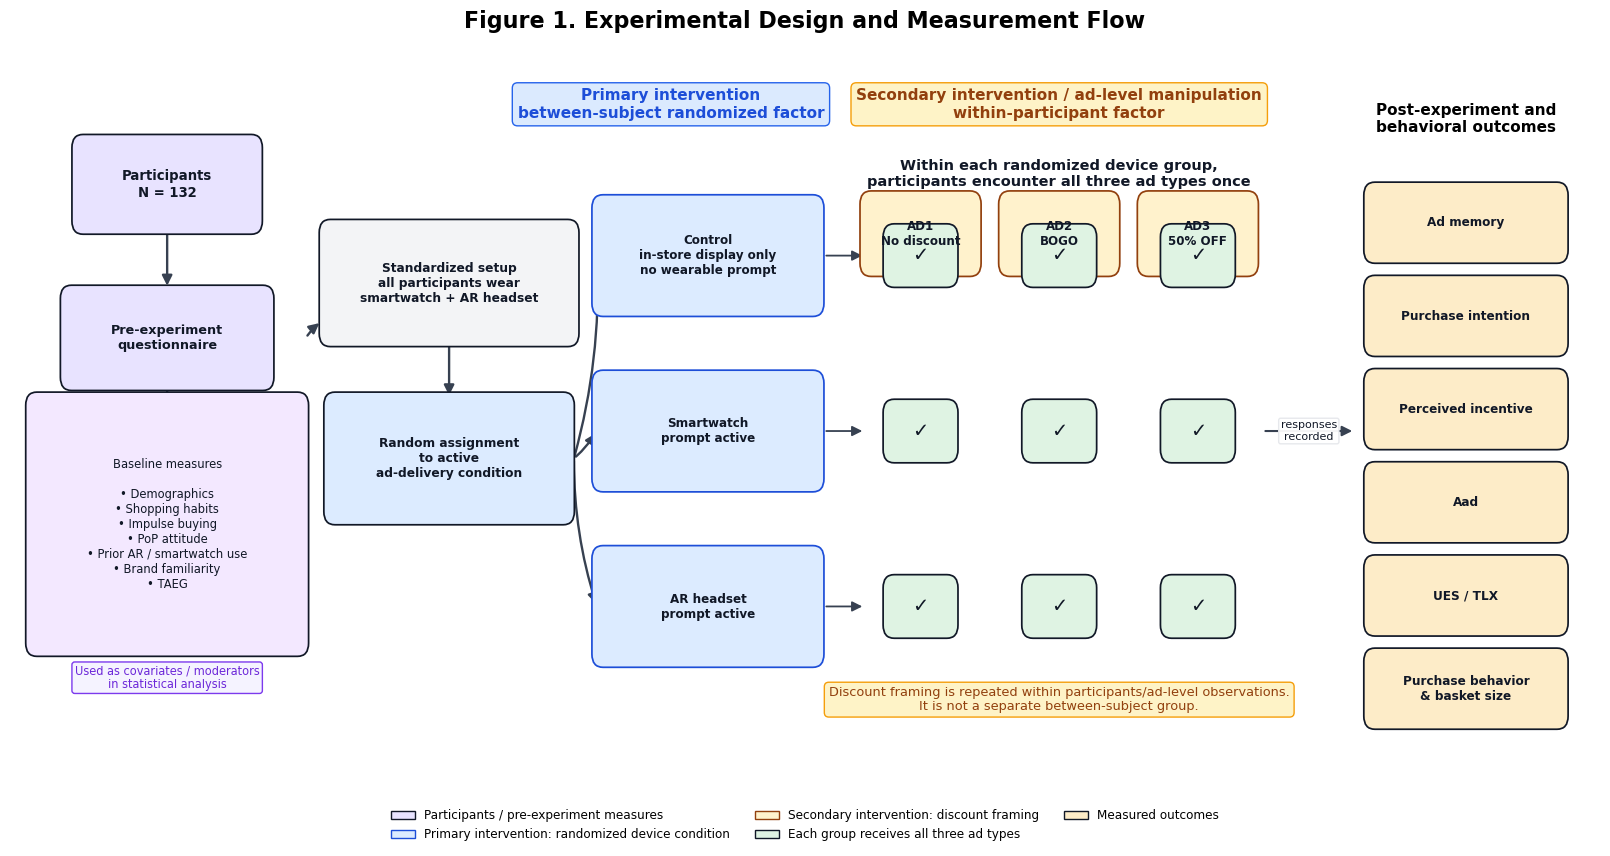

In [42]:
# ============================================================
# Figure 1. Experimental design and measurement flow
#
# Clearly shows:
#   Primary intervention:
#       Device condition = between-subject randomized factor
#
#   Secondary intervention / ad-level manipulation:
#       Discount framing = within-participant ad-level factor
#
# Every device group includes all three ad types once:
#   AD1 = No discount
#   AD2 = BOGO
#   AD3 = 50% OFF
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Patch


# ============================================================
# Helper functions
# ============================================================

def add_box(
    ax,
    xy,
    text,
    width=2.2,
    height=0.8,
    facecolor="#FFFFFF",
    edgecolor="#111827",
    fontsize=9.5,
    fontweight="bold",
    radius=0.12,
    zorder=3,
):
    x, y = xy

    box = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width,
        height,
        boxstyle=f"round,pad=0.03,rounding_size={radius}",
        linewidth=1.25,
        edgecolor=edgecolor,
        facecolor=facecolor,
        zorder=zorder,
    )
    ax.add_patch(box)

    ax.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight=fontweight,
        color="#111827",
        zorder=zorder + 1,
    )


def add_arrow(
    ax,
    start,
    end,
    label=None,
    color="#374151",
    linewidth=1.7,
    rad=0.0,
    linestyle="-",
    fontsize=8,
    label_offset=(0, 0),
):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=15,
        linewidth=linewidth,
        color=color,
        linestyle=linestyle,
        connectionstyle=f"arc3,rad={rad}",
        zorder=2,
    )
    ax.add_patch(arrow)

    if label:
        mx = (start[0] + end[0]) / 2 + label_offset[0]
        my = (start[1] + end[1]) / 2 + label_offset[1]

        ax.text(
            mx,
            my,
            label,
            ha="center",
            va="center",
            fontsize=fontsize,
            color="#111827",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="#E5E7EB",
                alpha=0.95,
            ),
            zorder=5,
        )


def save_fig(fig, filename_base):
    fig.savefig(f"{filename_base}.png", dpi=350, bbox_inches="tight")
    fig.savefig(f"{filename_base}.svg", bbox_inches="tight")
    print(f"Saved: {filename_base}.png")
    print(f"Saved: {filename_base}.svg")


# ============================================================
# Draw Figure 1
# ============================================================

def draw_fig1_experimental_design(filename_base="fig1_experimental_design"):
    fig, ax = plt.subplots(figsize=(16.2, 8.6))
    ax.set_facecolor("#FAFAFA")

    ax.set_title(
        "Figure 1. Experimental Design and Measurement Flow",
        fontsize=16,
        fontweight="bold",
        pad=18,
    )

    # ------------------------------------------------------------
    # Participants and pre-experiment measures
    # ------------------------------------------------------------

    add_box(
        ax,
        (-6.6, 2.45),
        "Participants\nN = 132",
        width=2.0,
        height=0.85,
        facecolor="#E8E3FF",
    )

    add_box(
        ax,
        (-6.6, 1.05),
        "Pre-experiment\nquestionnaire",
        width=2.25,
        height=0.9,
        facecolor="#E8E3FF",
        fontsize=9.2,
    )

    add_arrow(ax, (-6.6, 2.03), (-6.6, 1.5))

    add_box(
        ax,
        (-6.6, -0.65),
        "Baseline measures\n\n"
        "• Demographics\n"
        "• Shopping habits\n"
        "• Impulse buying\n"
        "• PoP attitude\n"
        "• Prior AR / smartwatch use\n"
        "• Brand familiarity\n"
        "• TAEG",
        width=3.0,
        height=2.35,
        facecolor="#F3E8FF",
        fontsize=8.3,
        fontweight="normal",
    )

    add_arrow(ax, (-6.6, 0.6), (-6.6, 0.1))

    ax.text(
        -6.6,
        -2.05,
        "Used as covariates / moderators\nin statistical analysis",
        ha="center",
        va="center",
        fontsize=8.2,
        color="#6D28D9",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="#F5F3FF",
            edgecolor="#7C3AED",
        ),
    )

    # ------------------------------------------------------------
    # Standardized setup
    # ------------------------------------------------------------

    add_box(
        ax,
        (-3.55, 1.55),
        "Standardized setup\nall participants wear\nsmartwatch + AR headset",
        width=2.75,
        height=1.1,
        facecolor="#F3F4F6",
        fontsize=8.8,
    )

    add_arrow(ax, (-5.1, 1.05), (-4.93, 1.2), rad=-0.08)

    # ------------------------------------------------------------
    # Primary intervention: randomized device condition
    # ------------------------------------------------------------

    ax.text(
        -1.15,
        3.18,
        "Primary intervention\nbetween-subject randomized factor",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#1D4ED8",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="#DBEAFE",
            edgecolor="#2563EB",
        ),
    )

    add_box(
        ax,
        (-3.55, -0.05),
        "Random assignment\nto active\nad-delivery condition",
        width=2.65,
        height=1.15,
        facecolor="#DCEBFF",
        fontsize=8.8,
    )

    add_arrow(ax, (-3.55, 1.0), (-3.55, 0.5))

    group_labels = [
        "Control\nin-store display only\nno wearable prompt",
        "Smartwatch\nprompt active",
        "AR headset\nprompt active",
    ]

    group_y = [1.8, 0.2, -1.4]

    for label, y in zip(group_labels, group_y):
        add_box(
            ax,
            (-0.75, y),
            label,
            width=2.45,
            height=1.05,
            facecolor="#DCEBFF",
            edgecolor="#1D4ED8",
            fontsize=8.6,
        )
        add_arrow(ax, (-2.2, -0.05), (-1.95, y), rad=0.08)

    # ------------------------------------------------------------
    # Secondary intervention / ad-level manipulation:
    # discount framing within each randomized group
    # ------------------------------------------------------------

    ax.text(
        3.05,
        3.18,
        "Secondary intervention / ad-level manipulation\nwithin-participant factor",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#92400E",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="#FEF3C7",
            edgecolor="#F59E0B",
        ),
    )

    ax.text(
        3.05,
        2.55,
        "Within each randomized device group,\nparticipants encounter all three ad types once",
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color="#111827",
    )

    discount_labels = [
        "AD1\nNo discount",
        "AD2\nBOGO",
        "AD3\n50% OFF",
    ]

    discount_x = [1.55, 3.05, 4.55]

    for label, x in zip(discount_labels, discount_x):
        add_box(
            ax,
            (x, 2.0),
            label,
            width=1.25,
            height=0.72,
            facecolor="#FFF2CC",
            edgecolor="#92400E",
            fontsize=8.5,
        )

    # Matrix cells: each device group receives all three ad types
    for y in group_y:
        for x in discount_x:
            add_box(
                ax,
                (x, y),
                "✓",
                width=0.75,
                height=0.52,
                facecolor="#DFF3E3",
                fontsize=14,
            )

    # Arrows from device groups to their ad rows
    for y in group_y:
        add_arrow(ax, (0.5, y), (0.95, y), color="#374151", linewidth=1.3)

    ax.text(
        3.05,
        -2.25,
        "Discount framing is repeated within participants/ad-level observations.\n"
        "It is not a separate between-subject group.",
        ha="center",
        va="center",
        fontsize=9.3,
        color="#92400E",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="#FEF3C7",
            edgecolor="#F59E0B",
        ),
    )

    # ------------------------------------------------------------
    # Outcomes
    # ------------------------------------------------------------

    outcome_x = 7.45

    outcome_nodes = [
        ("Ad memory", 2.1),
        ("Purchase intention", 1.25),
        ("Perceived incentive", 0.4),
        ("Aad", -0.45),
        ("UES / TLX", -1.3),
        ("Purchase behavior\n& basket size", -2.15),
    ]

    ax.text(
        outcome_x,
        3.05,
        "Post-experiment and\nbehavioral outcomes",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

    for label, y in outcome_nodes:
        add_box(
            ax,
            (outcome_x, y),
            label,
            width=2.15,
            height=0.68,
            facecolor="#FDECC8",
            fontsize=8.7,
        )

    add_arrow(
        ax,
        (5.25, 0.2),
        (6.25, 0.2),
        label="responses\nrecorded",
        color="#374151",
        linewidth=1.5,
    )

    # ------------------------------------------------------------
    # Legend
    # ------------------------------------------------------------

    legend_handles = [
        Patch(facecolor="#E8E3FF", edgecolor="#111827", label="Participants / pre-experiment measures"),
        Patch(facecolor="#DCEBFF", edgecolor="#1D4ED8", label="Primary intervention: randomized device condition"),
        Patch(facecolor="#FFF2CC", edgecolor="#92400E", label="Secondary intervention: discount framing"),
        Patch(facecolor="#DFF3E3", edgecolor="#111827", label="Each group receives all three ad types"),
        Patch(facecolor="#FDECC8", edgecolor="#111827", label="Measured outcomes"),
    ]

    ax.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=3,
        frameon=False,
        fontsize=8.7,
    )

    ax.set_xlim(-8.3, 8.9)
    ax.set_ylim(-3.1, 3.65)
    ax.axis("off")
    plt.tight_layout()

    save_fig(fig, filename_base)
    plt.show()


# ============================================================
# Run
# ============================================================

draw_fig1_experimental_design()

Saved: fig4_supported_hypotheses.png
Saved: fig4_supported_hypotheses.svg


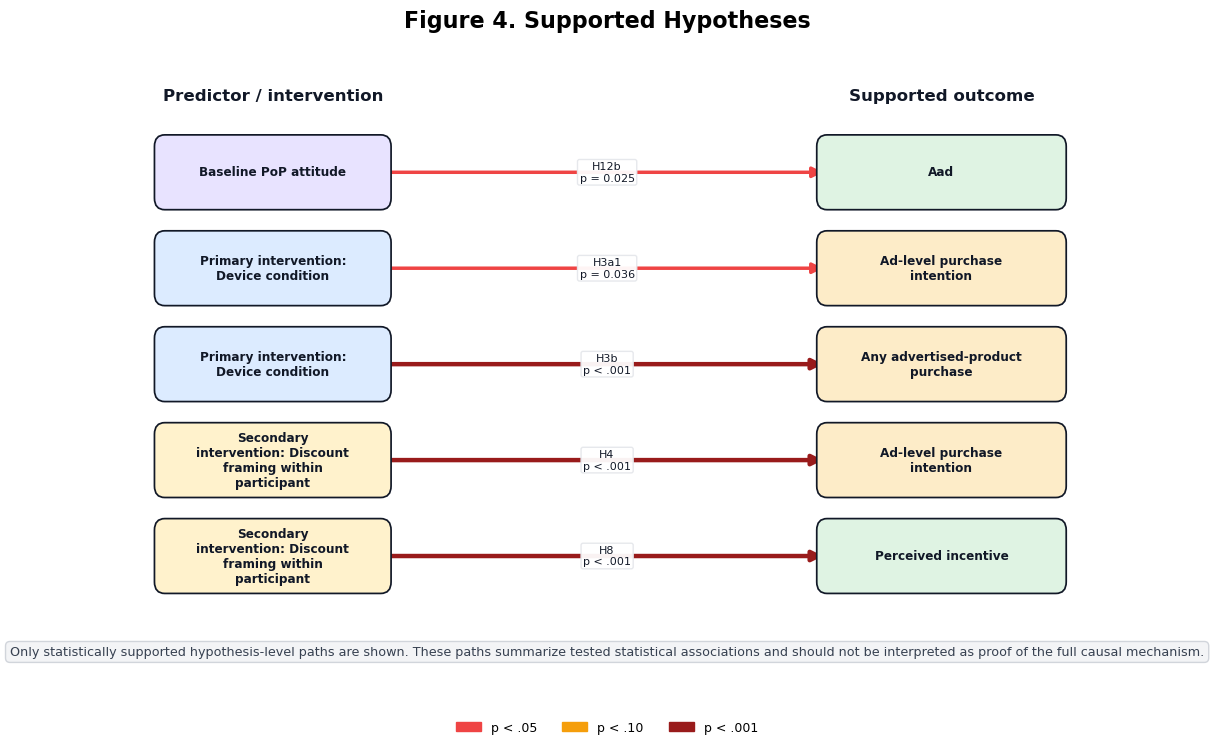

Saved: fig4_supported_hypotheses_including_marginal.png
Saved: fig4_supported_hypotheses_including_marginal.svg


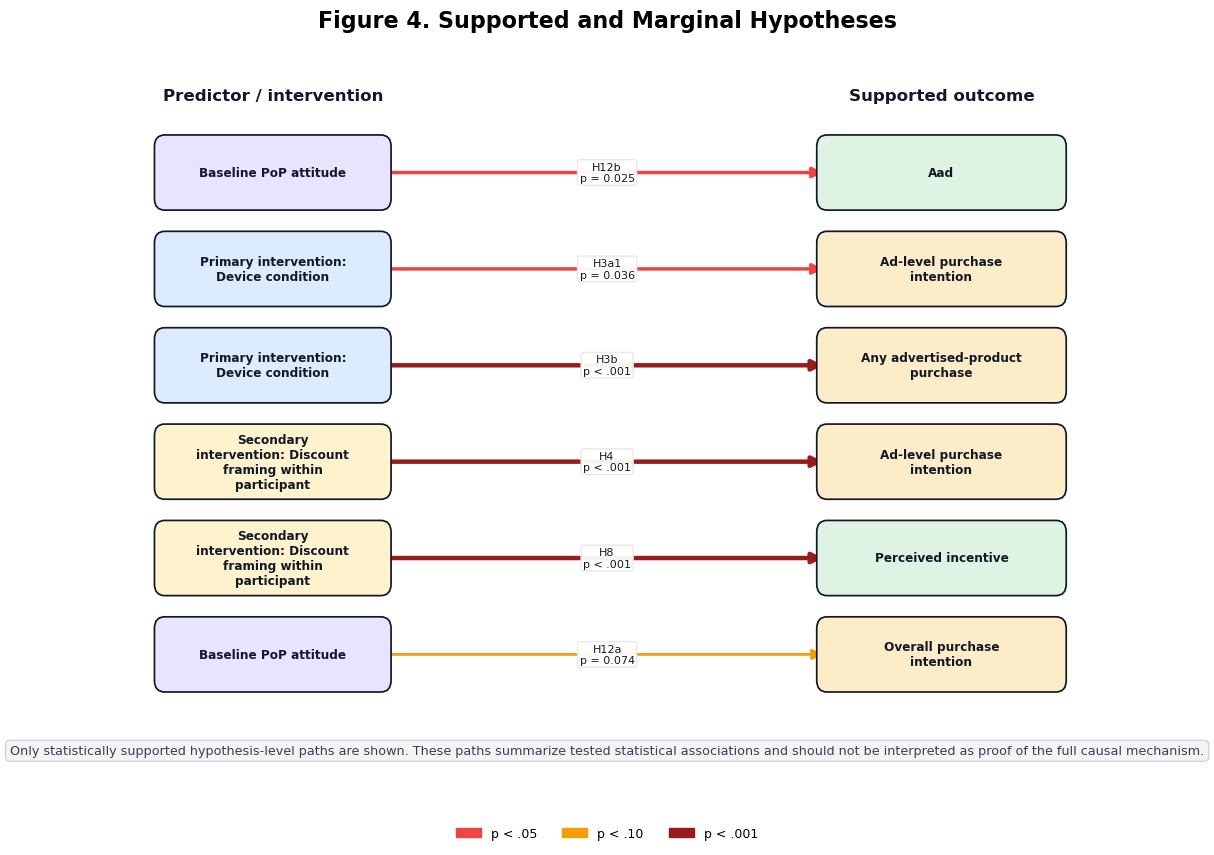

In [44]:
# ============================================================
# Figure 4. Supported hypotheses from results_df
# Clean journal-ready version with no crossing arrows
# ============================================================

ALL_EDGES_DF = pd.concat(
    [DIRECT_EDGES_DF, MODERATION_EDGES_DF],
    ignore_index=True
)


def node_color_all(node):
    if node == "Primary intervention:\nDevice condition":
        return "#DCEBFF"
    if node == "Secondary intervention:\nDiscount framing\nwithin participant":
        return "#FFF2CC"
    if "×" in str(node):
        return "#FFE6CC"
    if node in ["Workload (TLX)", "Baseline PoP attitude"]:
        return "#E8E3FF"
    if node in ["Ad memory", "Engagement (UES)", "Aad", "Perceived incentive"]:
        return "#DFF3E3"
    return "#FDECC8"


def supported_result_note(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "p < .001"
    return f"p = {p:.3f}"


def draw_supported_hypotheses(
    results_df,
    filename_base="fig4_supported_hypotheses",
    include_marginal=False,
):
    # ------------------------------------------------------------
    # Prepare result p-values
    # ------------------------------------------------------------

    res = results_df.copy()

    # Exclude controlled robustness checks
    res = res[
        ~res["hypothesis"].astype(str).str.contains("controlled", case=False, na=False)
    ].copy()

    p_lookup = res.set_index("hypothesis")["p_value"].to_dict()

    edges = ALL_EDGES_DF.copy()
    edges["p_value"] = edges["hypothesis"].map(p_lookup)

    if include_marginal:
        edges = edges[
            edges["p_value"].notna() &
            (edges["p_value"] < 0.10)
        ].copy()

        title = "Figure 4. Supported and Marginal Hypotheses"
        fname = filename_base + "_including_marginal"

    else:
        edges = edges[
            edges["p_value"].notna() &
            (edges["p_value"] < 0.05)
        ].copy()

        title = "Figure 4. Supported Hypotheses"
        fname = filename_base

    if len(edges) == 0:
        print("No supported hypothesis edges found at this threshold.")
        return

    # ------------------------------------------------------------
    # Journal-friendly ordering
    # Put the clearest paths first.
    # Extra significant paths, if any, are added after these.
    # ------------------------------------------------------------

    preferred_order = [
        "H12b",   # Baseline PoP attitude -> Aad
        "H3a1",   # Device condition -> ad-level purchase intention
        "H3b",    # Device condition -> advertised-product purchase
        "H4",     # Discount framing -> ad-level purchase intention
        "H8",     # Discount framing -> perceived incentive

        # If these are significant/marginal in another run, they appear next
        "H2",
        "H3a",
        "H3b1",
        "H5a",
        "H5b",
        "H6",
        "H7",
        "H9a",
        "H9b",
        "H9c",
        "H9d",
        "H10a",
        "H10b",
        "H10c",
        "H10d",
        "H11a",
        "H11b",
        "H12a",
    ]

    order_map = {h: i for i, h in enumerate(preferred_order)}
    edges["plot_order"] = edges["hypothesis"].map(order_map).fillna(999)
    edges = edges.sort_values(["plot_order", "hypothesis"]).reset_index(drop=True)

    # ------------------------------------------------------------
    # Figure size
    # ------------------------------------------------------------

    n_paths = len(edges)
    fig_height = max(5.8, 1.05 * n_paths + 2.3)

    fig, ax = plt.subplots(figsize=(12.5, fig_height))
    ax.set_facecolor("#FAFAFA")

    # ------------------------------------------------------------
    # Layout settings
    # ------------------------------------------------------------

    source_x = -3.9
    target_x = 3.9
    arrow_start_x = -2.55
    arrow_end_x = 2.55

    top_y = n_paths - 1
    y_positions = list(range(top_y, -1, -1))

    # Column headers
    ax.text(
        source_x,
        top_y + 0.8,
        "Predictor / intervention",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#111827",
    )

    ax.text(
        target_x,
        top_y + 0.8,
        "Supported outcome",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#111827",
    )

    # ------------------------------------------------------------
    # Draw each supported path as one row
    # This avoids crossing arrows.
    # ------------------------------------------------------------

    for i, (_, row) in enumerate(edges.iterrows()):
        y = y_positions[i]

        source = row["source"]
        target = row["target"]
        hyp = row["hypothesis"]
        p = row["p_value"]

        color, width = edge_style_from_p(p)

        # Source box
        add_box(
            ax,
            (source_x, y),
            wrap_text(source, 22),
            width=2.7,
            height=0.72,
            facecolor=node_color_all(source),
            fontsize=8.7,
        )

        # Target box
        add_box(
            ax,
            (target_x, y),
            wrap_text(target, 24),
            width=2.85,
            height=0.72,
            facecolor=node_color_all(target),
            fontsize=8.7,
        )

        # Straight arrow
        add_arrow(
            ax,
            (arrow_start_x, y),
            (arrow_end_x, y),
            label=f"{hyp}\n{supported_result_note(p)}",
            color=color,
            linewidth=width,
            rad=0.0,
            fontsize=8.0,
        )

    # ------------------------------------------------------------
    # Note
    # ------------------------------------------------------------

    note_y = -1.0

    ax.text(
        0,
        note_y,
        (
            "Only statistically supported hypothesis-level paths are shown. "
            "These paths summarize tested statistical associations and should not be interpreted "
            "as proof of the full causal mechanism."
        ),
        ha="center",
        va="center",
        fontsize=9.2,
        color="#374151",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="#F3F4F6",
            edgecolor="#D1D5DB",
        ),
    )

    # ------------------------------------------------------------
    # Legend
    # ------------------------------------------------------------

    legend_handles = [
        Patch(facecolor="#EF4444", edgecolor="#EF4444", label="p < .05"),
        Patch(facecolor="#F59E0B", edgecolor="#F59E0B", label="p < .10"),
        Patch(facecolor="#991B1B", edgecolor="#991B1B", label="p < .001"),
    ]

    ax.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.07),
        ncol=3,
        frameon=False,
        fontsize=9,
    )

    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=18,
    )

    ax.set_xlim(-5.8, 5.8)
    ax.set_ylim(-1.5, top_y + 1.25)
    ax.axis("off")
    plt.tight_layout()

    save_fig(fig, fname)
    plt.show()


# ============================================================
# Run Figure 4
# ============================================================

draw_supported_hypotheses(
    results_df,
    filename_base="fig4_supported_hypotheses",
    include_marginal=False,
)

draw_supported_hypotheses(
    results_df,
    filename_base="fig4_supported_hypotheses",
    include_marginal=True,
)

## 14. Save outputs to CSV

In [ ]:
reliability_df.to_csv(OUTPUT_DIR / "reliability_summary.csv", index=False)
manip_ct.to_csv(OUTPUT_DIR / "manipulation_confusion_matrix.csv")
manip_summary_df.to_csv(OUTPUT_DIR / "manipulation_summary.csv", index=False)
notice_df.to_csv(OUTPUT_DIR / "noticing_by_group.csv", index=False)
subject_descriptives.to_csv(OUTPUT_DIR / "subject_level_descriptives_by_group.csv", index=False)
ad_descriptives.to_csv(OUTPUT_DIR / "ad_level_descriptives_by_group_discount.csv", index=False)
results_df.to_csv(OUTPUT_DIR / "hypothesis_results_no_gaze.csv", index=False)

print("Saved files to:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p.name)


## 15. Optional: save figures to PNG

In [ ]:
# Example for saving current / repeated figures:
# fig.savefig(OUTPUT_DIR / "figure_name.png", dpi=200, bbox_inches="tight")
print("Uncomment fig.savefig(...) lines in the plotting cells if you want PNG outputs.")
